<div class="colab-button-container">
  <a href="https://colab.research.google.com/drive/1CUDyNMz2TQrY2Ekpco1aWJ-ibvSVdIRF?usp=sharing"
     target="_blank"
     class="colab-top-button"
     title="Open this notebook in Google Colab">
    <img src="https://colab.research.google.com/assets/colab-badge.svg"
         alt="Open in Colab"
         class="colab-badge">
  </a>
</div>

---
format:
  html:
    page-layout: full
    mainfont: "Inter"
    toc: true
---

<h1>Introductory scRNA-seq Analysis with `kb-python` and `Scanpy`</h1>
<h4>Written by Maya Caskey (based off older versions by Joe Rich, Kyung Hoi (Joseph) Min, A. Sina Booeshaghi and Lior Pachter)</h4>
<br>

This notebook demonstrates pre-processing and basic analysis of the [1k Human PBMCs](https://www.10xgenomics.com/datasets/1-k-human-pbm-cs-stained-with-a-panel-of-total-seq-b-antibodies-single-indexed-3-1-standard-4-0-0) dataset from 10x Genomics using the **10x Genomics Chromium Single Cell 3' Next Gen v3.1** assay.

## An Introductory Analysis Workflow

There are many ways to perform a single-cell RNA sequencing (scRNA-seq) analysis and many aspects of your data to explore. In this tutorial, we outline a basic approach to quality control and analysis, along with some intuitive explanation of the underlying mathematics.

:::{.highlight-section}
This scRNA-seq workflow has the following steps:

1. Read Pseudoalignment
2. Quality Control
3. Cell and Gene Filters
4. Normalization and Variance Stabilization
5. Dimensionality Reduction
6. Clustering and Visualization
7. Cell Type Annotation
8. Differential Expression Analysis
:::

:::{.callout-note title="Working with Multiple Samples"}
This workflow is designed for a single sample, but the same principles apply when working with multiple samples. When analyzing multiple samples, it is important to perform quality control and filtering (Steps 2-3) on each sample separately to avoid batch effects distorting your results. After cell filtering, you can combine samples for downstream analysis using `anndata.concat()`. If samples have technical differences and do not cluster together, you may need to apply batch correction methods before dimensionality reduction and clustering. If this is the case, we recommend using the batch correction tool [Harmony](https://scanpy.readthedocs.io/en/latest/generated/scanpy.external.pp.harmony_integrate.html).
:::

## Initial Set-Up

### Install Python Packages

In [1]:
# @title
!pip install --quiet scanpy python-igraph pybiomart
!pip install --quiet matplotlib
!pip install --quiet scikit-learn
!pip install --quiet numpy
!pip install --quiet scipy

!pip install --quiet kb-python
!pip install --quiet scikit-image

In [2]:
import shutil

# kb-python ships its own kallisto/bustools binaries, which is all that's
# needed on Colab. If kallisto/bustools are also installed locally (e.g. via
# conda), point kb at those instead of its bundled binaries.
_kallisto_bin = shutil.which("kallisto")
_bustools_bin = shutil.which("bustools")
KB_BIN_FLAGS = (
    f"--kallisto {_kallisto_bin} --bustools {_bustools_bin}"
    if _kallisto_bin and _bustools_bin
    else ""
)

In [3]:
# Import packages
import anndata
import os
import matplotlib
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.decomposition import TruncatedSVD
from scipy import sparse, io

matplotlib.rcParams.update({'font.size': 12})
set_matplotlib_formats('retina')

In [4]:
import warnings
warnings.filterwarnings('ignore')

### Download the scRNA-seq data

In [5]:
!wget -nc https://cf.10xgenomics.com/samples/cell-exp/4.0.0/SC3_v3_NextGem_SI_PBMC_CSP_1K/SC3_v3_NextGem_SI_PBMC_CSP_1K_fastqs.tar
if not os.path.exists("SC3_v3_NextGem_SI_PBMC_CSP_1K_fastqs"):
    !tar -xf SC3_v3_NextGem_SI_PBMC_CSP_1K_fastqs.tar

File ‘SC3_v3_NextGem_SI_PBMC_CSP_1K_fastqs.tar’ already there; not retrieving.



## Step 1: Read Pseudoalignment

### Download a Pre-Built Index with `kb ref`

In [ ]:
!kb ref -d human -i sc_data/index.idx -g sc_data/t2g.txt $KB_BIN_FLAGS

### Pseudoalign Reads to Reference with `kb count`

Here we use `kb count` to pseudoalign our reads to the reference transcriptome and generate a count matrix. This should be done for each sample separately. Here we have only one sample, so we will run `kb count` once. The data for a single sample can be distributed across multiple files corresponding to different lanes or sequencing runs, but they should all be pseudoaligned together to generate a single count matrix for that sample.

In [ ]:
# This step runs `kb` to pseudoalign the reads, and then generate the cells x gene matrix in h5ad format.
!kb count -i sc_data/index.idx -g sc_data/t2g.txt -o sc_data -x 10XV3 --h5ad -t 2 $KB_BIN_FLAGS \
SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_fastqs/SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_gex_fastqs/SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_gex_S1_L002_R1_001.fastq.gz \
SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_fastqs/SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_gex_fastqs/SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_gex_S1_L002_R2_001.fastq.gz \
SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_fastqs/SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_gex_fastqs/SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_gex_S1_L003_R1_001.fastq.gz \
SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_fastqs/SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_gex_fastqs/SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_gex_S1_L003_R2_001.fastq.gz \
SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_fastqs/SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_gex_fastqs/SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_gex_S1_L004_R1_001.fastq.gz \
SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_fastqs/SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_gex_fastqs/SC3_v3_NextGem_SI_CSP-Labeled_PBMCs_1K_gex_S1_L004_R2_001.fastq.gz

When the `--h5ad` argument is used, `kb count` generates a H5AD-formatted Anndata matrix for downstream processing.

### Load the Anndata Object

For this tutorial we will be using the Python package [**Scanpy**](https://scanpy.readthedocs.io/en/stable/).

Scanpy is a scalable Python library for analyzing single-cell RNA sequencing (scRNA-seq) data, built around an efficient [**AnnData**](https://anndata.readthedocs.io/en/stable/) object that stores expression matrices and associated metadata. It provides a comprehensive toolkit for preprocessing, visualization, clustering, and differential expression, enabling end-to-end analysis of large single-cell datasets.

Below we load the *cells x genes* matrix generated by kb-python as a H5AD-formatted object so that we can analyze our data with Scanpy.

In [ ]:
# import data
adata = anndata.read_h5ad('sc_data/counts_unfiltered/adata.h5ad')
adata

In [ ]:
# Load the gene names and make them a column in the var dataframe
with open("sc_data/counts_unfiltered/cells_x_genes.genes.names.txt", 'r') as file:
  adata.var['gene_names'] = [l.strip() for l in file.readlines()]

## Step 2: Basic Quality Control

### Test for Library Saturation

Below is a **Gene vs. UMI plot**, in which, for each cell, we visualize how many genes we detected. The purpose of this plot is to see if we have "saturated" our sequencing library and sampled a representative number of mRNA molecules for each cell. If this is the case, the curve should plateau as we sequence more UMIs.

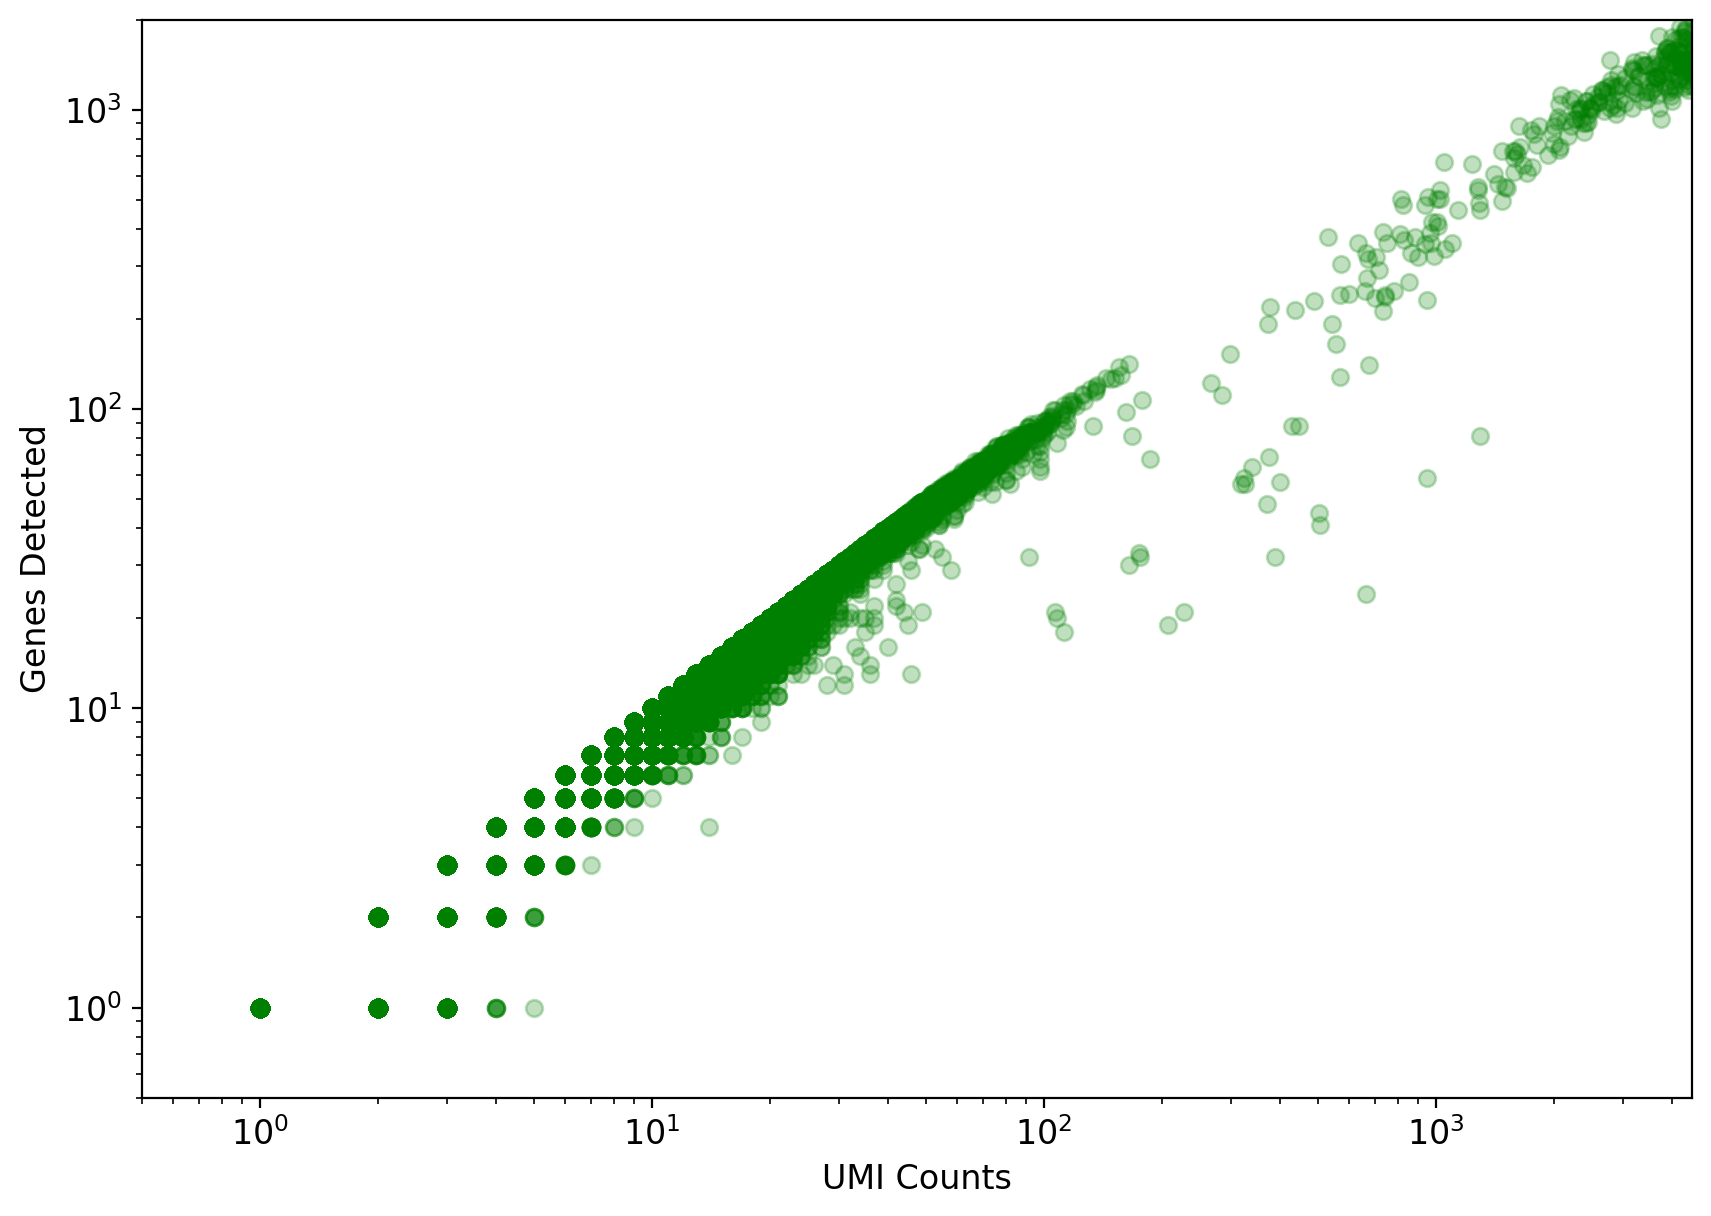

In [10]:
# Create a plot showing genes detected as a function of UMI counts.
fig, ax = plt.subplots(figsize=(10, 7))

x = np.asarray(adata.X.sum(axis=1))[:,0]
y = np.asarray(np.sum(adata.X>0, axis=1))[:,0]

ax.scatter(x, y, color="green", alpha=0.25)
ax.set_xlabel("UMI Counts")
ax.set_ylabel("Genes Detected")
ax.set_xscale('log')
ax.set_yscale('log', nonpositive='clip')

ax.set_xlim((0.5, 4500))
ax.set_ylim((0.5,2000))


plt.show()

The number of genes detected continues to increase with the number of UMI counts (x-axis) indicating that we have not saturated our library. More sequencing would likely yield more genes detected per cell.

### Examine the Knee Plot

Single-cell RNA-seq experiments generate a large number of **barcode sequences**, each of which may correspond to a real cell or to background signal. In practice, many barcodes capture little or no cellular RNA due to technical noise, ambient RNA, or incomplete barcoding reactions.

The **knee plot** helps distinguish barcodes associated with real cells from those representing background. It was first introduced in the [Drop-seq paper by Macosko et al., 2015](https://www.cell.com/fulltext/S0092-8674(15)00549-8).

In this plot, barcodes are ranked by their total number of **UMI counts**. The y-axis shows the ranked barcodes, while the x-axis shows the number of UMIs associated with each barcode (typically on a log scale). A sharp transition — the **“knee”** of the curve — separates barcodes with high UMI counts (likely real cells) from those with very low counts (likely background).

In droplet-based platforms such as **10x Genomics**, low-count barcodes often correspond to **empty droplets containing ambient RNA**. In other single-cell methods, such as **combinatorial indexing approaches like Split-seq**, low-count barcodes may arise from incomplete barcoding or background capture. In both cases, the knee plot provides a useful heuristic for identifying barcodes that likely correspond to real cells.

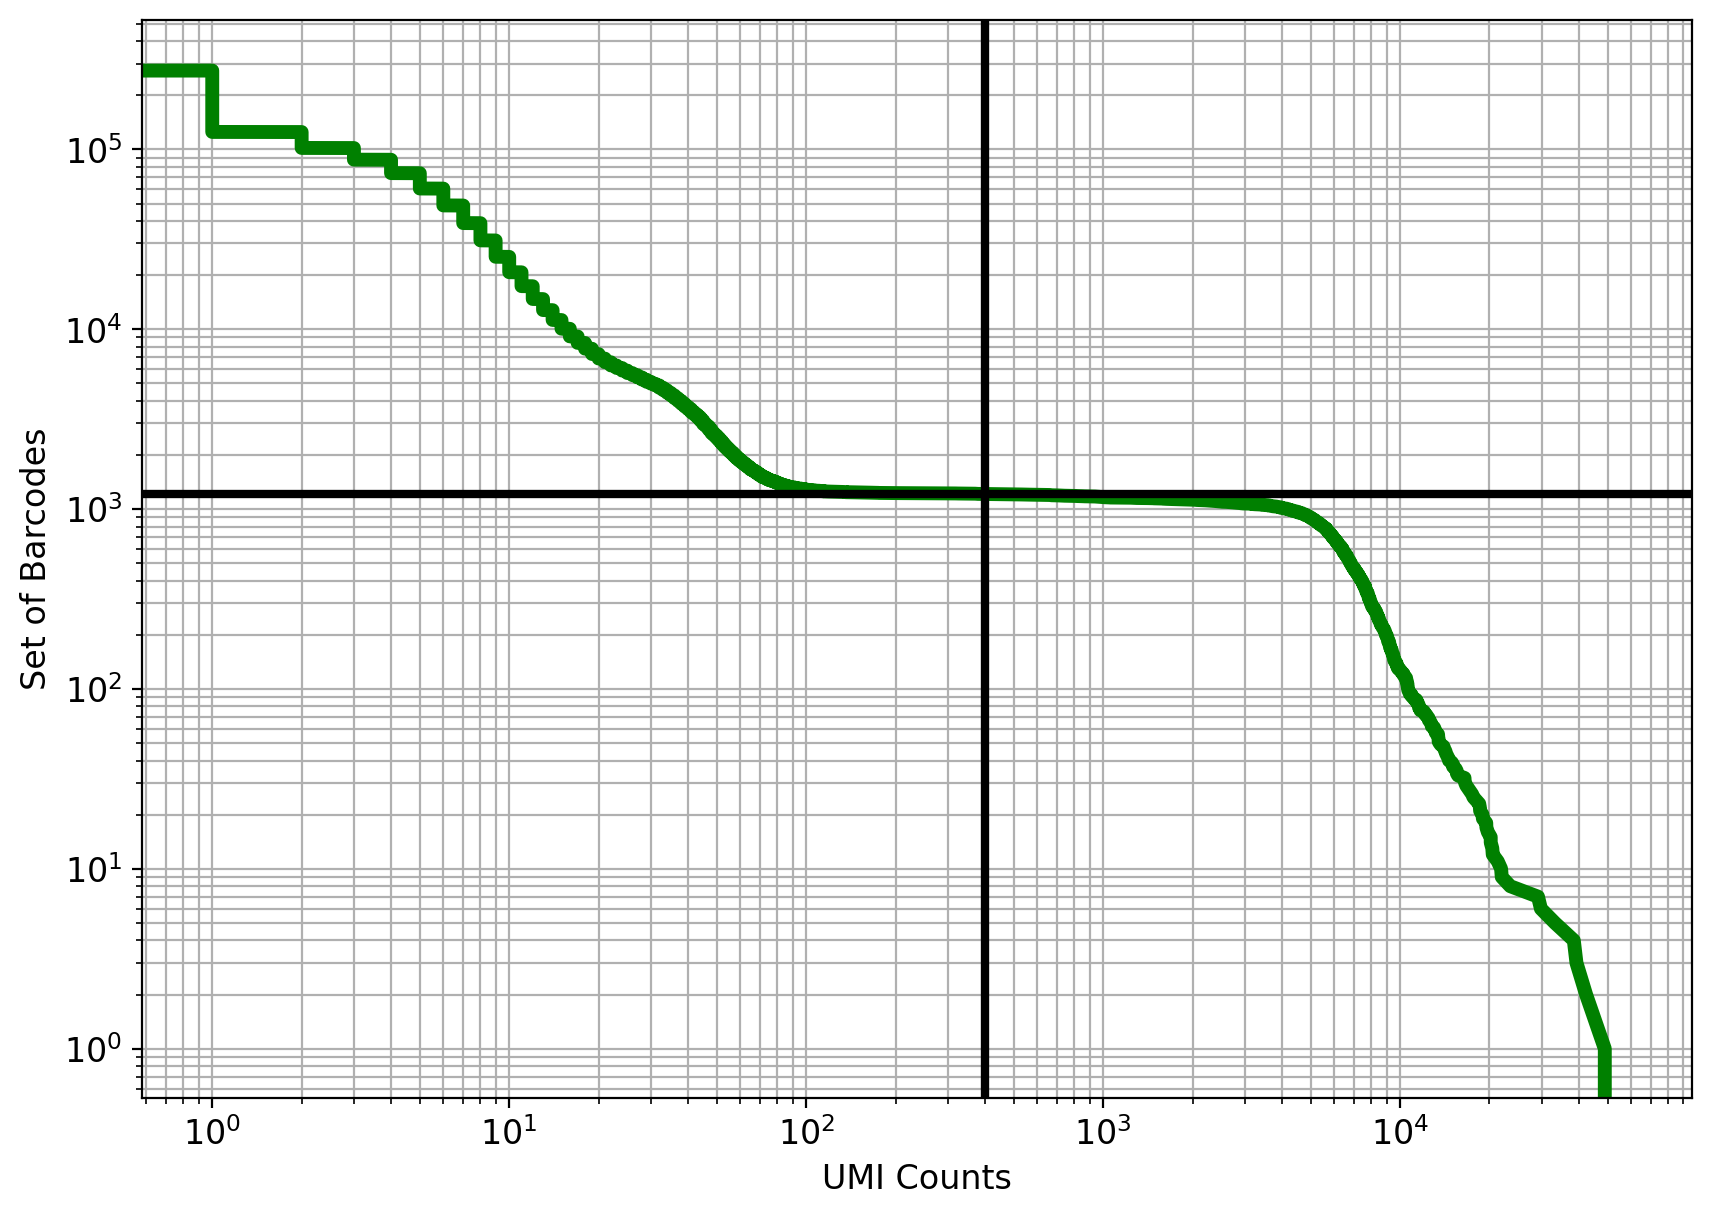

In [11]:
#@title Threshold Cells According to Knee Plot { run: "auto", vertical-output: true }
cutoff = 400  #@param {type:"integer"}
knee = np.sort((np.array(adata.X.sum(axis=1))).flatten())[::-1]
cell_set = np.arange(len(knee))
num_cells = cell_set[knee > cutoff][::-1][0]

fig, ax = plt.subplots(figsize=(10, 7))


ax.loglog(knee, cell_set, linewidth=5, color="g")
ax.axvline(x=cutoff, linewidth=3, color="k")


ax.axhline(y=num_cells, linewidth=3, color="k")

ax.set_xlabel("UMI Counts")
ax.set_ylabel("Set of Barcodes")

plt.grid(True, which="both")
plt.show()

In [12]:
print(f"{num_cells:,.0f} cells passed the {cutoff} UMI threshold")

1,212 cells passed the 400 UMI threshold


## Step 3: Gene and Cell Filtering

### Filter empty droplets (According to the Knee Plot)

Ideally, your data will contain no empty droplets that can be mistaken for real cells. We use our results from the knee plot here to filter them out. In addition, we filter out low-quality cells that have fewer than 200 detected genes.

In [13]:
# Filter the cells according to the threshold determined from the knee plot
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_cells(adata, min_counts=knee[num_cells])

:::{.callout-note}
The knee plot is a very simple method for getting rid of empty droplets. More sophisticated methods also exist. For instance, the method [**EmptyDrops**](https://link.springer.com/article/10.1186/s13059-019-1662-y) uses a statistical model to distinguish cell-containing droplets from empty droplets. It can be employed on both 10X and Parse data.
:::

### Filter Multiplets with Scrublet

In any high-throughput single-cell RNA-seq experiment, a small fraction of barcodes will capture more than one cell, resulting in **multiplets** (also called **doublets** when two cells are captured together). These multiplets can confound downstream analyses by appearing as hybrid cell types that do not correspond to any real biological state.

[**Scrublet**](https://github.com/swolock/scrublet) is a package designed to identify and remove multiplets from scRNA-seq data. It works by simulating artificial doublets through random pairwise combinations of real cells’ expression profiles. Scrublet then embeds both the simulated and observed cells in a low-dimensional space and flags real cells that lie close to simulated doublets as potential multiplets.

Scrublet operates on a raw count matrix, but requires that empty droplets be removed beforehand. If empty droplets remain in the dataset, they can distort the simulated doublet distribution and lead to inaccurate classifications. In addition, the Scrublet package should be applied to each sample/batch individually to avoid batch effects distorting the simulated doublet distribution.

Removing multiplets is an important quality-control step, as doublets can appear as hybrid cell types and obscure true biological variation during clustering and downstream analyses.

:::{.callout-note}
The Scrublet package is convenient because it is built into Scanpy, but it is not the only nor the most accurate doublet removal method. For a review of doublet detection methods, refer to the paper [Benchmarking computational doublet-detection methods for single-cell RNA sequencing data](https://pmc.ncbi.nlm.nih.gov/articles/PMC7897250/) by Nan Miles Chi and Jingyi Jessica Li.
:::


In [14]:
sc.pp.scrublet(adata, expected_doublet_rate=0.008)

The expected doublet rate depends upon your assay and the number of cells targeted. Refer to the documentation for your specific technology to get this number. We got the expected doublet rate of 0.008 for 1,000 cells for 10x Chromium NextGem v3.1 [here](https://kb.10xgenomics.com/s/article/360054599512-What-is-the-cell-multiplet-rate-when-using-the-3-CellPlex-Kit-for-Cell-Multiplexing).

In [15]:
adata = adata[adata.obs['predicted_doublet'] == False]

### Filtering Cells by Mitochondrial Content

A healthy, intact cell should have relatively little mitochondrial RNA in the cytoplasm. As such, a high percentage of mitochondrial RNA in the cytosol indicates cellular damage. We will identify the number of mitochondrial transcripts in each cell and remove cells with a certain percentage of mitochondrial content.

In [16]:
# Identify mitochondrial genes based on human-specific mtRNA prefix
adata.var['is_mito'] = adata.var['gene_names'].str.startswith("MT-")

mito_counts = adata[:, adata.var['is_mito']].X.sum(axis=1)

# Calculate total counts per cell
total_counts = adata.X.sum(axis=1)

# Calculate percent mitochondrial gene expression per cell
adata.obs['percent_mito'] = np.array(mito_counts / total_counts * 100).flatten()

adata.obs['n_counts'] = adata.X.sum(axis=1).A1

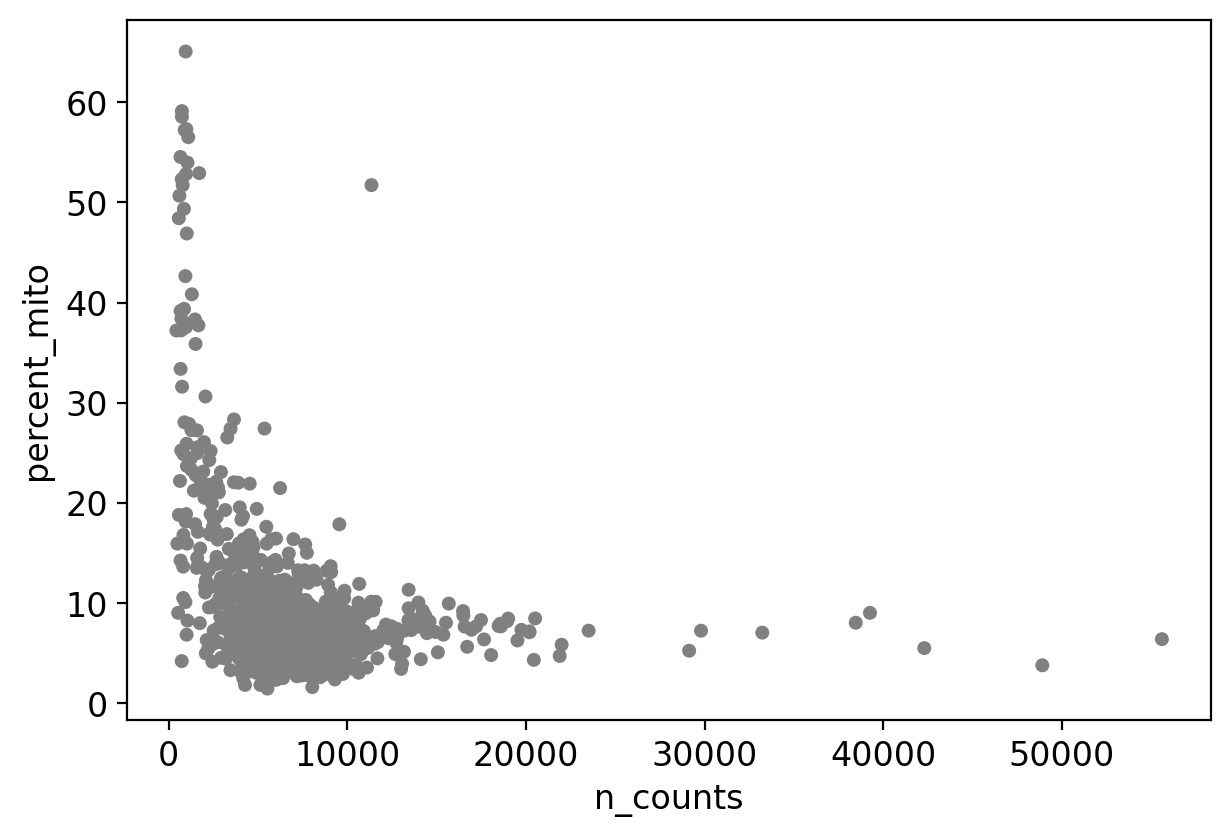

In [17]:
sc.pl.scatter(adata, x='n_counts', y='percent_mito')

We see above that the highest density of cells appear to have less than 30% mitochondrial content, so we will set our threshold to 30%

In [18]:
adata = adata[adata.obs.percent_mito < 30]

### Filter out genes that are not present in any cells

In general, we also want to get rid of genes with a low cell count to simplify our data. This is not strictly necessary, but it can make downstream analyses more efficient and easier to interpret. We will filter out genes that are not detected in at least 3 cells.

In [19]:
sc.pp.filter_genes(adata, min_cells=3)

:::{.callout-important}
In the case that you have multiple samples, gene filtering should be performed after concatenating samples into a single adata object using `adata.concat`. This is because the same gene may be expressed in different samples, and filtering genes separately for each sample may lead to inconsistent gene sets across samples.
:::

### Visualizing count distributions

Examination of the gene count and UMI count distributions is useful QC to evaluate the quality of the library and how deeply it was sequenced.

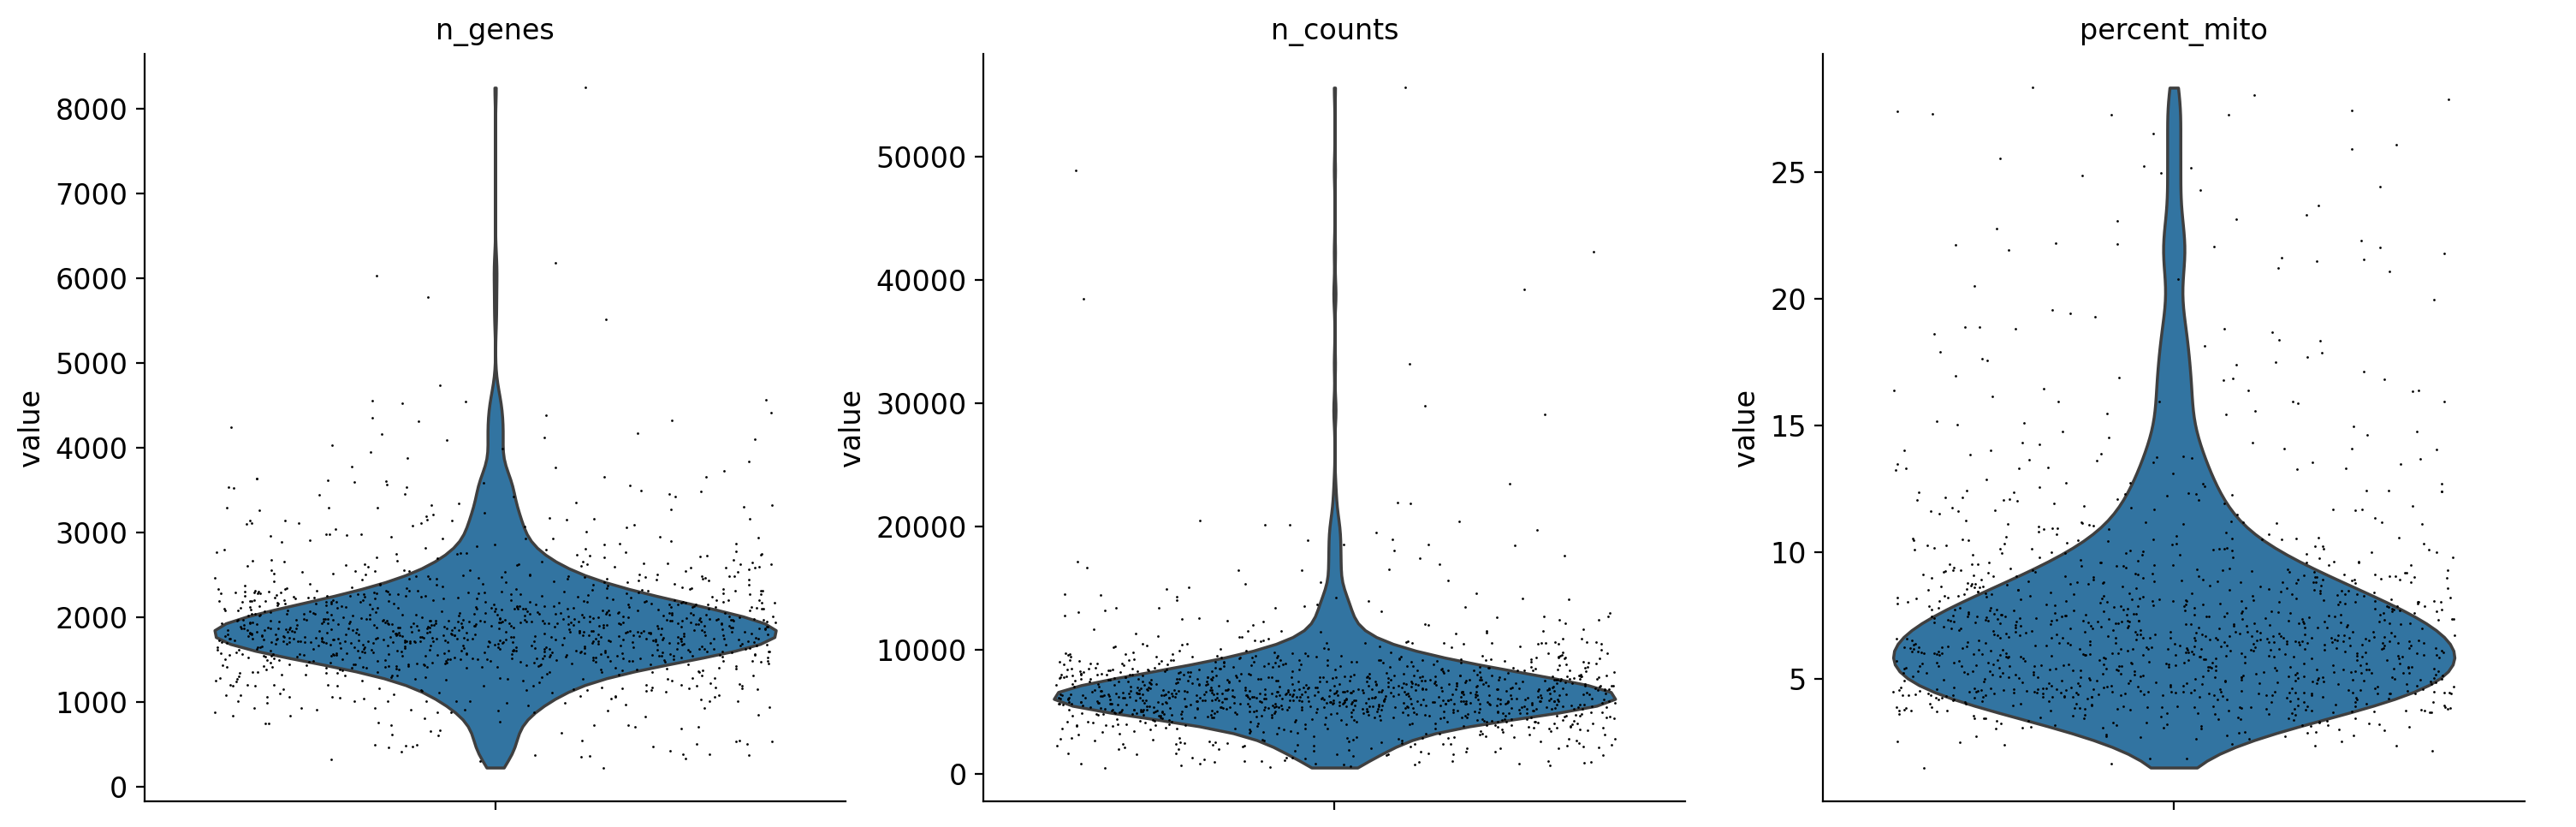

In [20]:
sc.pl.violin(adata, ['n_genes', 'n_counts', 'percent_mito'], jitter=0.4, multi_panel=True)

## Step 4: Normalization and Variance Stabilization

In an scRNA-seq experiment, UMI counts provide a relative estimate of transcript abundance within each cell. During library preparation and sequencing, mRNA molecules from different cells are reverse transcribed and sequenced to varying degrees. As a result, UMI counts cannot be interpreted as absolute measurements of RNA abundance.

To make counts comparable across cells, we normalize the data so that each cell has a total of 1×10⁶ counts. This scaling preserves integer values while allowing gene expression levels to be expressed as relative abundances within each cell.

Downstream analyses such as PCA and differential expression typically assume that gene expression values are approximately continuous and have roughly constant variance across their range. However, raw scRNA-seq counts are **overdispersed** — they follow a negative binomial–like distribution, where the variance increases faster than the mean. To stabilize the variance and make the data more compatible with these methods, we apply a **log transformation** to the normalized counts. 

:::{.callout-note}
This is a simplified approach for addressing overdispersion. Although log normalization is widely used, it does not entirely produce constant-variance data. More sophisticated methods (e.g., variance-stabilizing transformations or model-based approaches) can better correct for overdispersion, but no perfect method currently exists — and those techniques are beyond the scope of this tutorial.
:::

In [21]:
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.log1p(adata)

### Highly Variable Gene (HVG) Selection
To simplify our data and reduce its dimensionality for downstream analyses, we limit our dataset to highly variable genes. Genes with low expression variance — such as housekeeping genes — contribute little to distinguishing between cell types or states, and can be excluded without loss of biological signal.

The standard method for identifying highly variable genes in Scanpy is to Here, we retain only genes with a mean expression between 0.01 and 8 (values above 8 likely indicate technical artifacts) and a minimum normalized dispersion of 1. Cells are grouped (binned) by mean gene expression, and genes within each bin are filtered based on their normalized dispersion values.

:::{.callout-note}
The sc.pp.highly_variable_genes(flavor="seurat") function in Scanpy expects input data that have already been normalized and variance-stabilized. This is only one highly variable gene selection method
:::

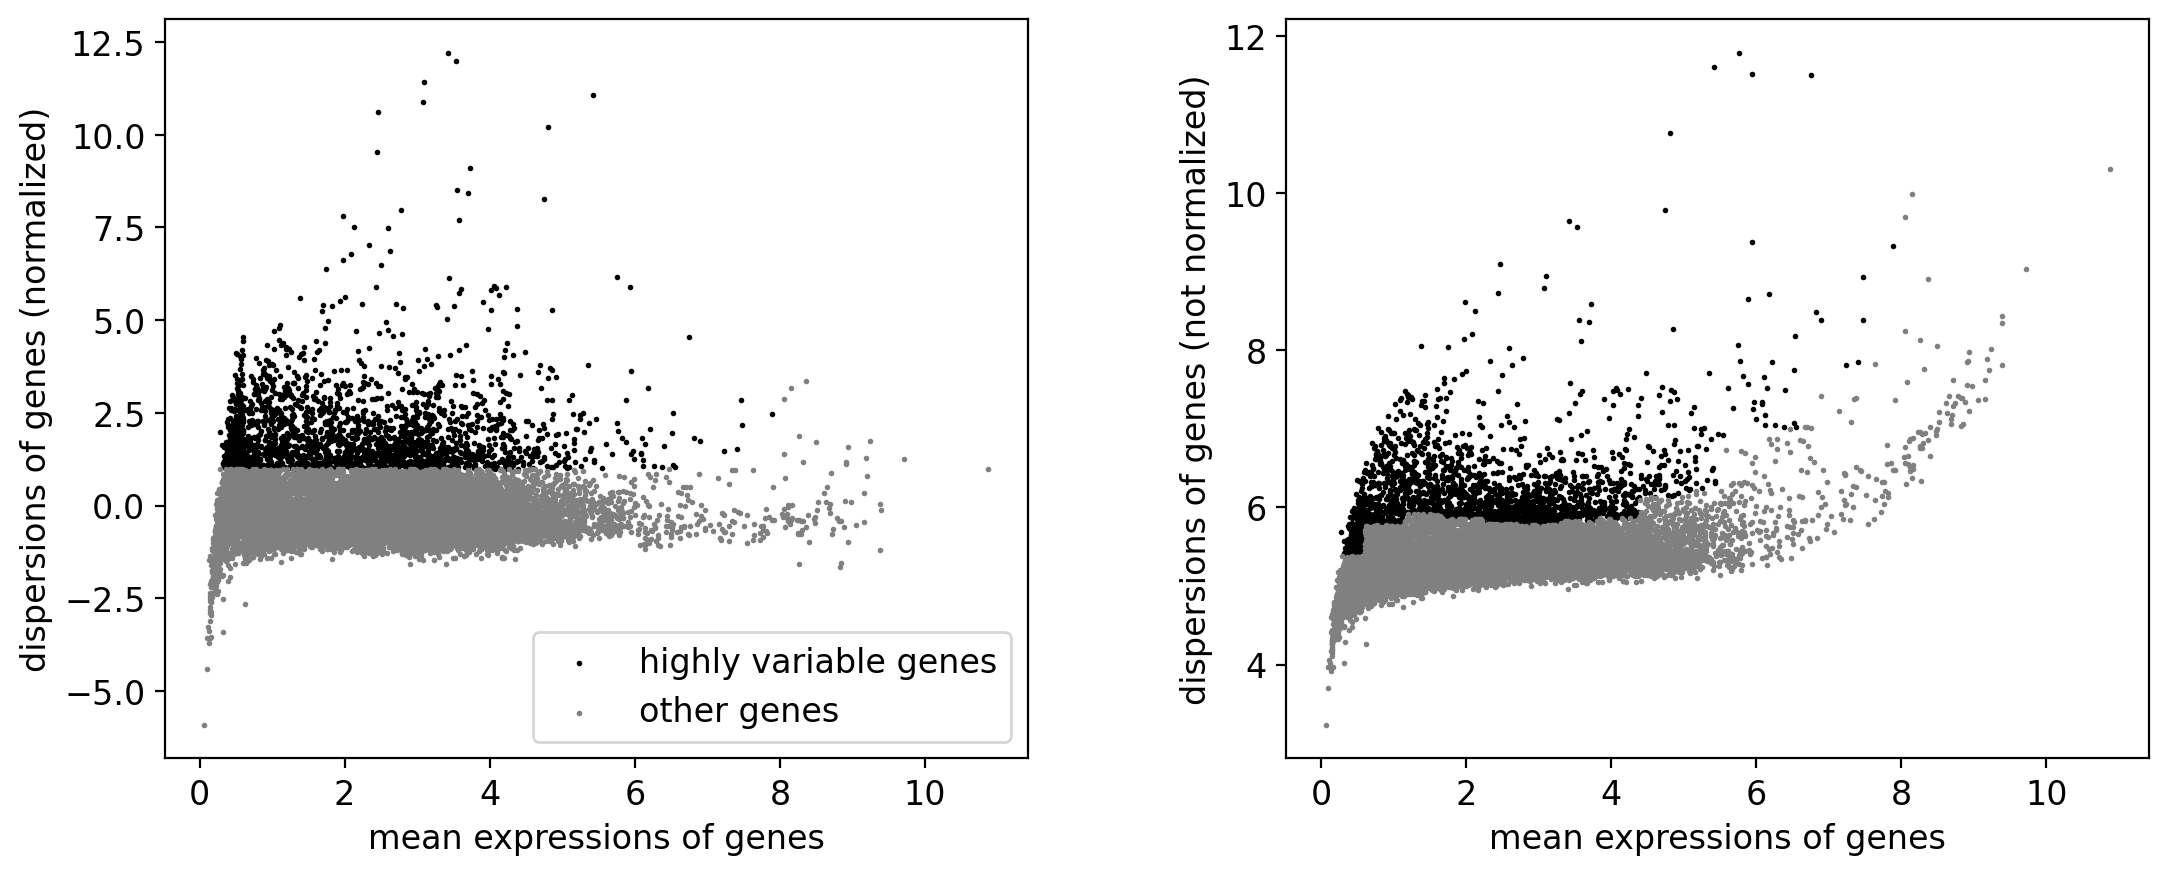

In [22]:
sc.pp.highly_variable_genes(adata, min_mean=0.01, max_mean=8, min_disp=1, n_bins=20, flavor="seurat")
sc.pl.highly_variable_genes(adata)

## Step 5: Clustering and Visualization

There are many algorithms for clustering cells, and while they have been compared in detail in various benchmarks (see e.g., [Duo et al. 2018](https://f1000research.com/articles/7-1141/v2)), there is no universally agreed upon method. Here we demonstrate clustering using **Leiden clustering**, which is a popular method for clustering single-cell RNA-seq data.

:::{.callout-note}
Leiden clustering is a non-deterministic algorithm, meaning it can produce slightly different results across runs. The number and size of clusters depend on a resolution parameter, which controls the granularity of the clustering. There is no universally optimal way to choose this parameter — it typically depends on how specific or fine-grained you want your cell populations to be.
:::

In [23]:
sc.pp.pca(adata, mask_var="highly_variable")

In [24]:
# Cluster the cells using Leiden clustering
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=10, knn=True)
sc.tl.leiden(adata, resolution = 1.0, flavor='igraph')

It is useful to revisit the PCA projection with points colored by cluster. Previously we computed the PCA projection directly; here we use a function in Scanpy which does the same.

### Visualization with PCA

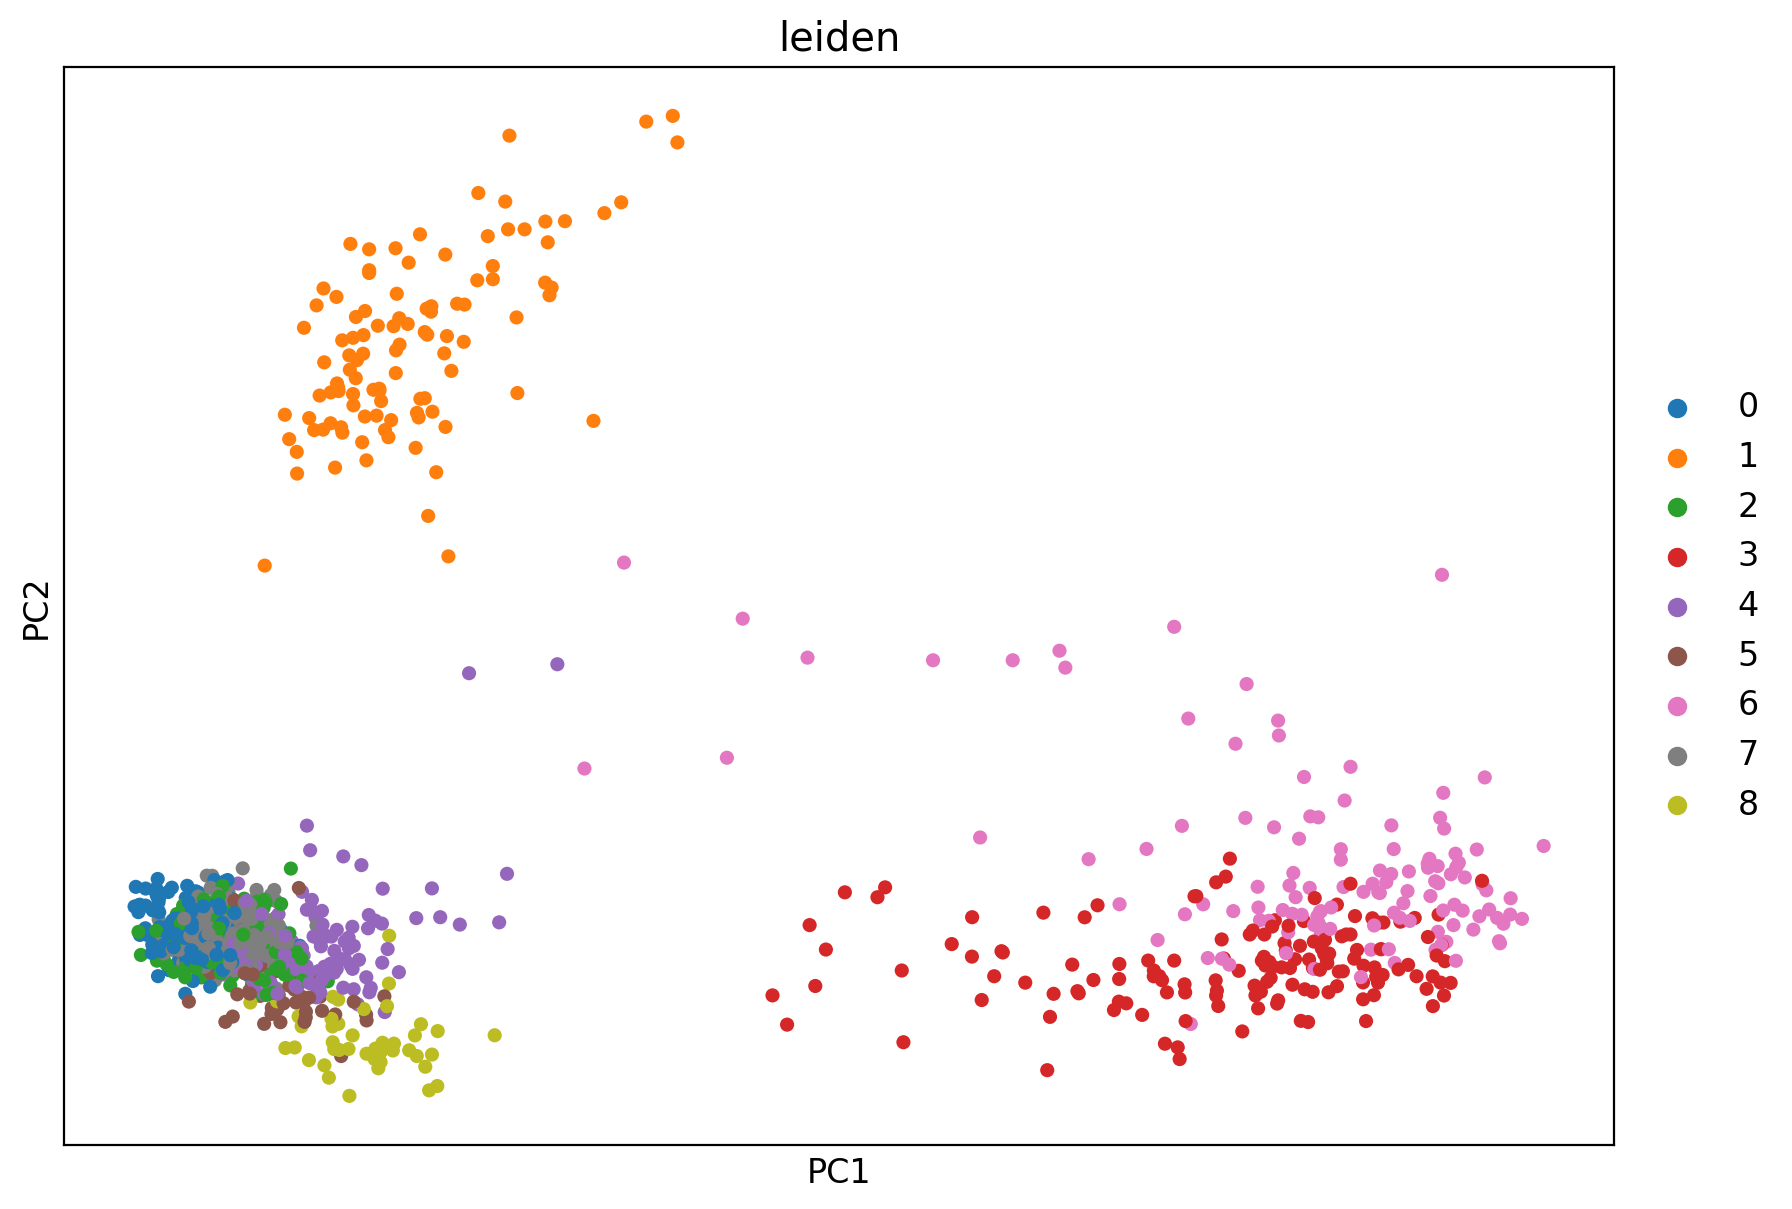

In [25]:
# Perform PCA and plot the projection to the first two dimensions, with points colored according to the Leiden clusters.
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.pca(adata, color='leiden', ax=ax)

### Nonlinear Visualization

The PCA representation results from a linear projection of the data from its original high-dimensional space to a lower-dimensional one (in this case, 2D). Such projections are valuable because they preserve global structure and are mathematically well-defined and reproducible.

In contrast, non-linear dimensionality reduction methods---the most popular being **t-SNE** and **UMAP**---can reveal complex, curved relationships in the data that linear methods cannot capture. However, they distort global distances and relationships, depend heavily on algorithmic parameters and random initialization, and may produce different results across runs. As a result, they are excellent for visualization but should be interpreted cautiously and not used for quantitative downstream analysis.

To read more, please see the [Pachter Lab's paper](http://biorxiv.org/lookup/doi/10.1101/2021.08.25.457696) on the drawbacks of non-linear dimensionality reduction methods.

#### t-SNE

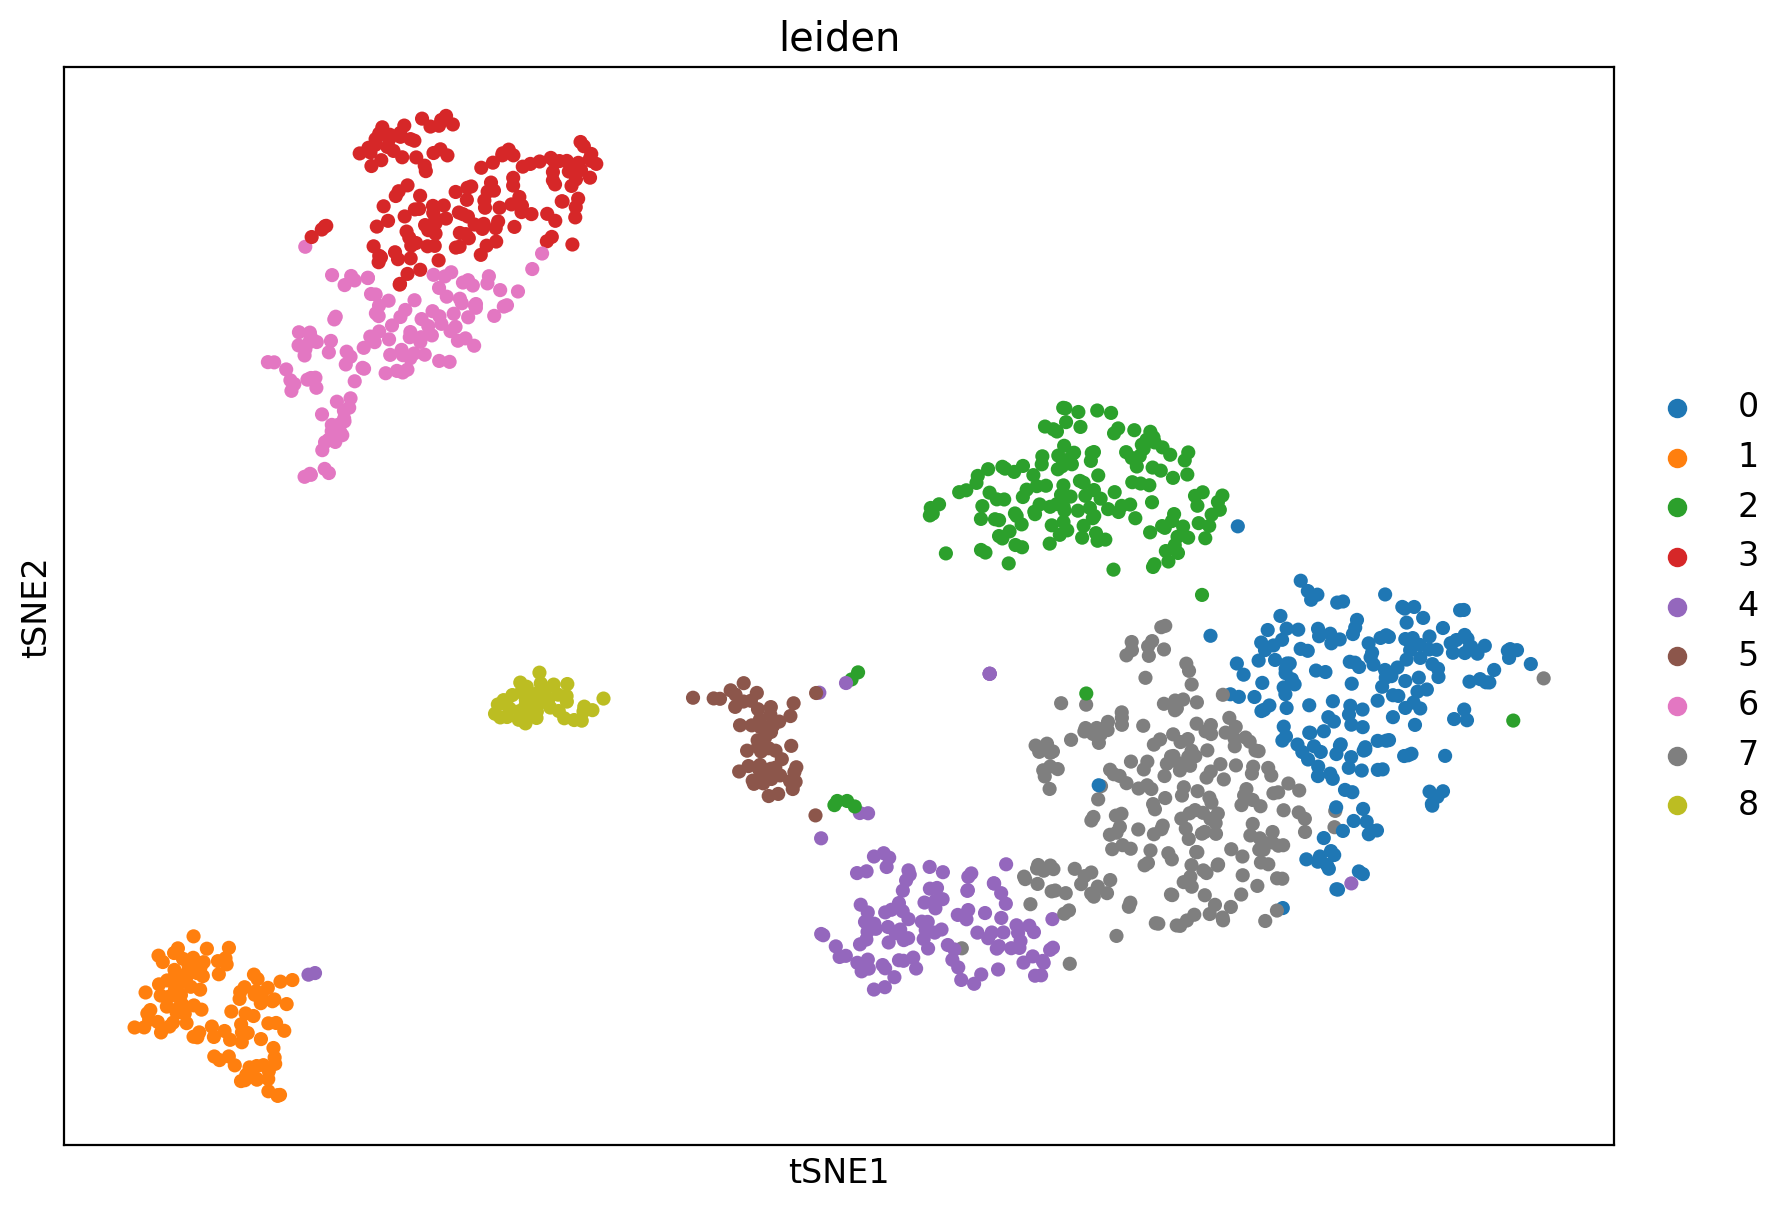

In [26]:
# Visualize cells with t-SNE. The n_pcs parameter sets the number of principal components to project to prior to
# performing t-SNE
sc.tl.tsne(adata, n_pcs=10)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.tsne(adata, color='leiden', ax=ax)

#### UMAP

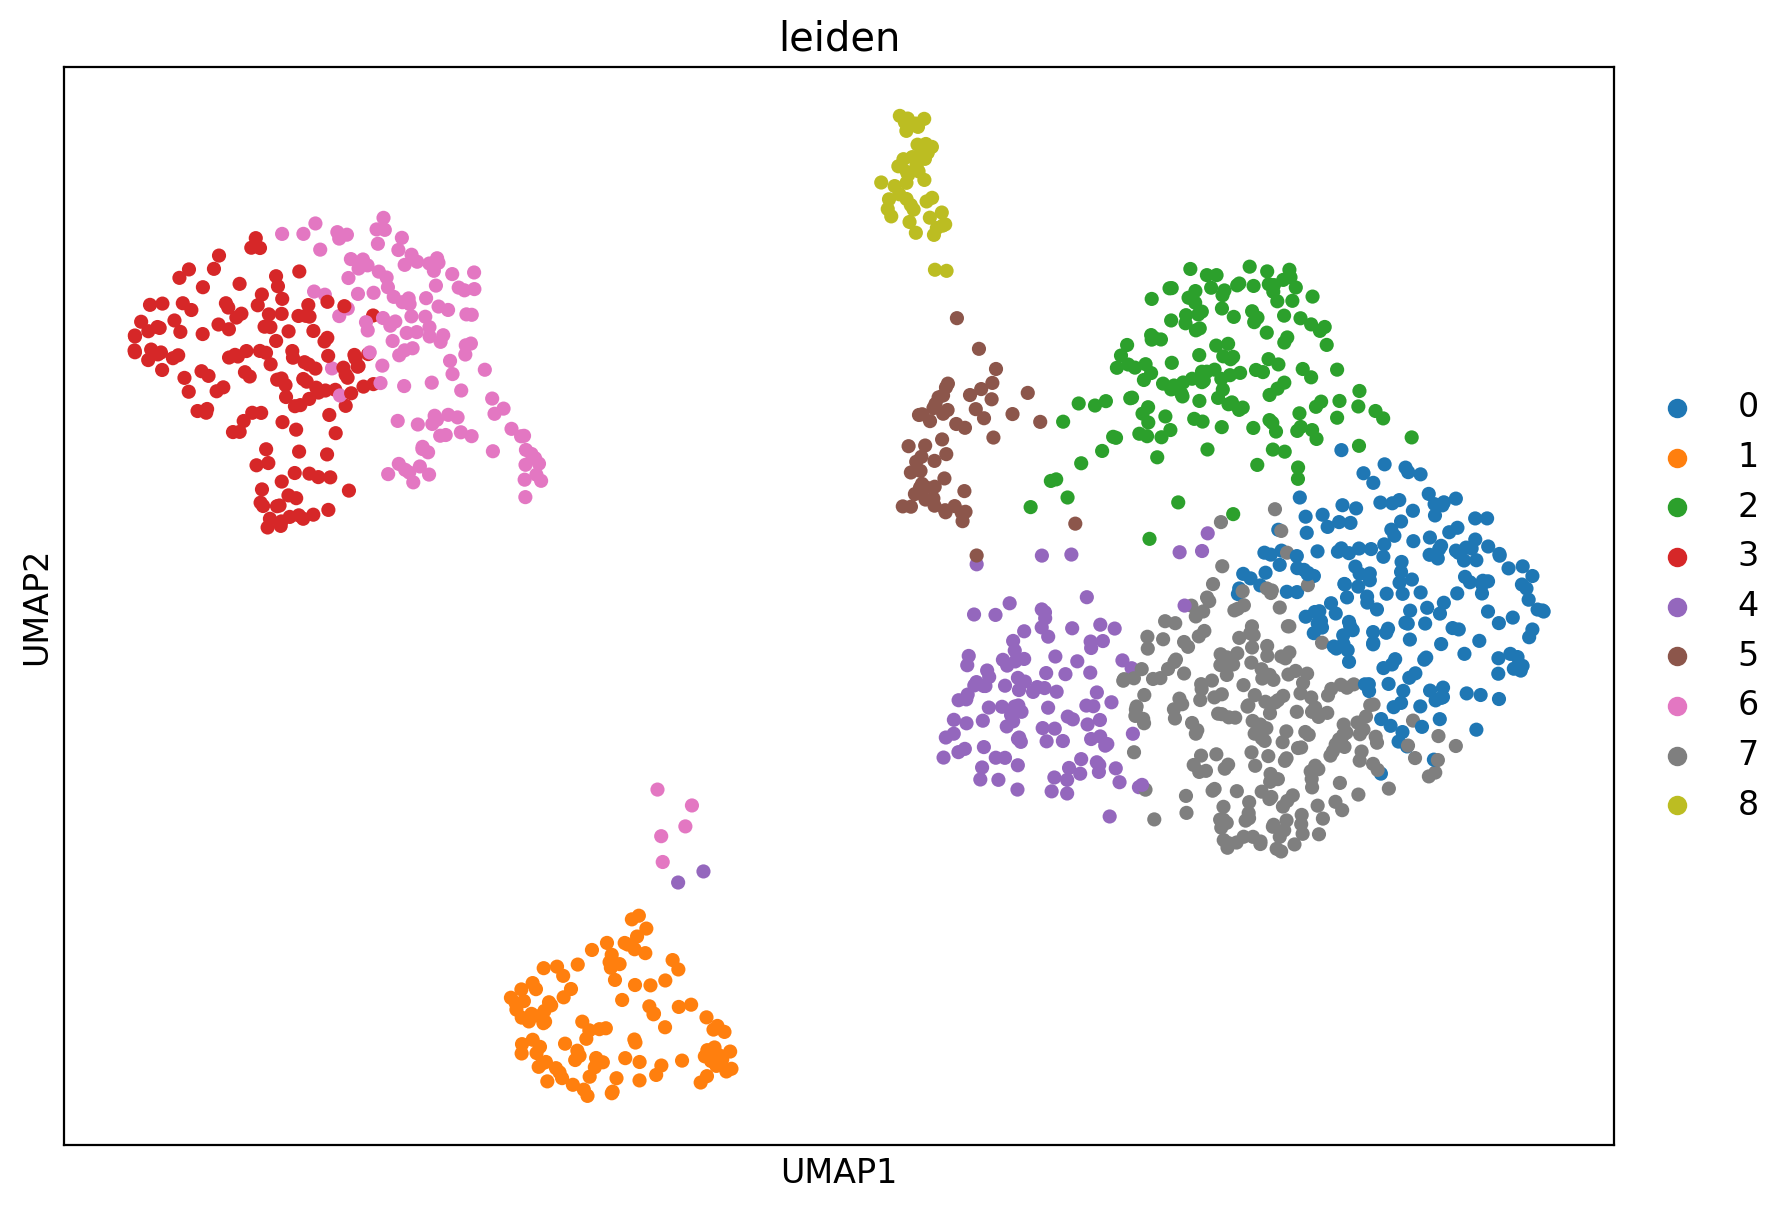

CPU times: user 2.65 s, sys: 863 ms, total: 3.51 s
Wall time: 1.56 s


In [27]:
%%time
sc.tl.umap(adata)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(adata, color='leiden', ax=ax)

## Step 6: Cell Type Annotation

There exist several methods for automatic cell-type annotation or annotation of cell-types from an atlas. However, these methods depend heavily on the reliability of the reference data and often still require manual refinements. For the sake of simplicity, we will not cover those here. Instead, we will go over manual annotation of cell-types. There are two stages to manual annotation that we can alternate between annotating by cluster differential expression and annotating by marker gene sets.

### Annotation by Differential Expression

From our clustering of cell states, we can perform a statistical test to identify genes that distinguish one cell state or cluster from another. This is typically done using simple statistical tests — such as the **Wilcoxon rank-sum test** or the **t-test** — which compare gene expression levels between clusters, or alternatively by fitting a more complex statistical model that accounts for variability across cells. By examining which genes are upregulated in each cluster, we can annotate clusters with known cell identities or infer novel cellular subpopulations.

Below, we use the **Wilcoxon rank-sum test** to identify marker genes. Because we are performing multiple hypothesis tests on the same dataset, we must adjust our p-values to control the false discovery rate. Several correction methods exist, but here we apply the **Benjamini–Hochberg procedure**, a widely used approach for multiple testing correction.

:::{.callout-note}
Statistical tests such as the **Wilcoxon rank-sum test** and the **t-test** assume that the groups being compared were defined independently of the data. However, in single-cell analysis, clustering algorithms like Leiden define groups based on the data itself — by minimizing within-cluster variation and maximizing between-cluster separation. This violates the independence assumption, meaning these tests are not strictly valid. Despite this, they remain common in practice and can still provide useful exploratory insights when interpreted cautiously.
:::

In [28]:
sc.tl.rank_genes_groups(adata, gene_symbols='gene_names', groupby='leiden', method='wilcoxon')

The below plot shows the 10 most highly expressed genes in each cluster (compared to the other clusters) according to the Wilcoxon z-score. We usually inspect these genes to determine if they correspond to known marker genes for specific cell types, which can help us annotate our clusters with putative cell identities.

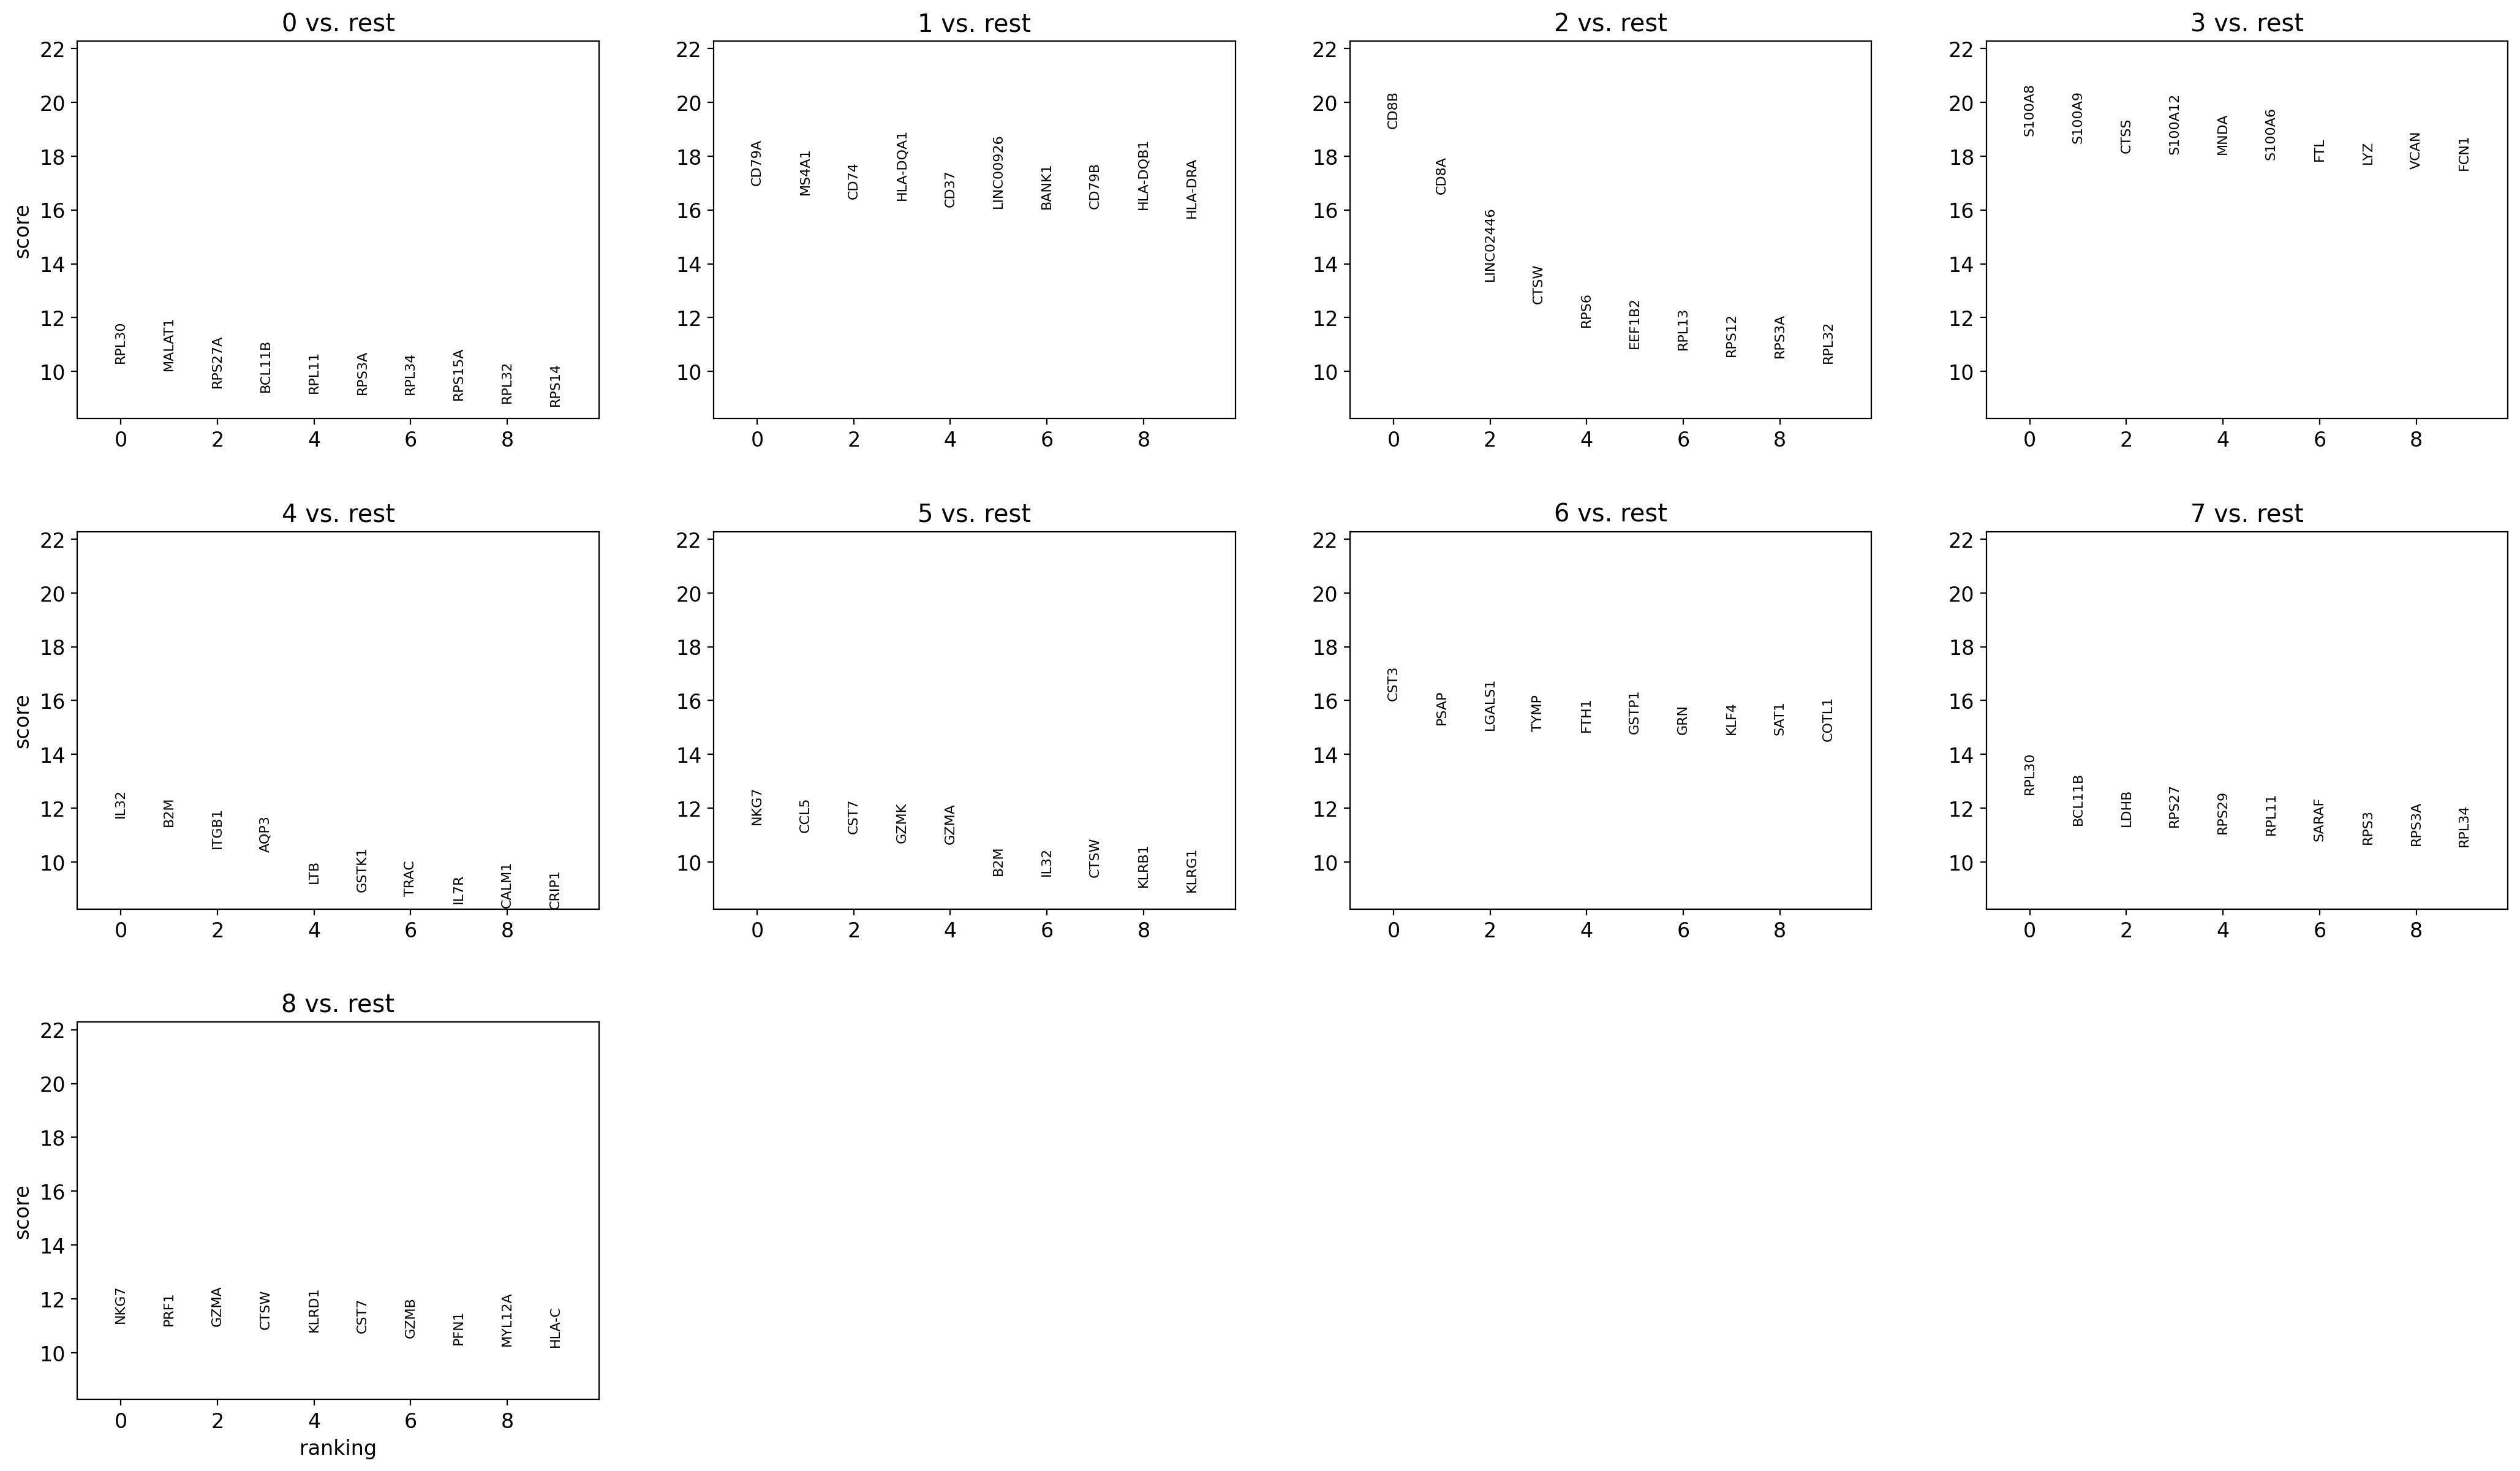

In [29]:
sc.pl.rank_genes_groups(adata, n_genes=10, gene_symbols='gene_names', groupby='leiden', method='wilcoxon')

Here we only display the top ten representative genes for each cluster. We find that differential expression in many of these clusters is driven by differential expression of highly but ubiquitously expressed genes (e.g. ribosomal protein-coding genes (RPS/RPL) and MALAT1, an abundant nuclear transcript). The relative expression of these genes is cell-type and cell-state specific but they make for unclear markers; we will remove them and perform the rank-sum test again.

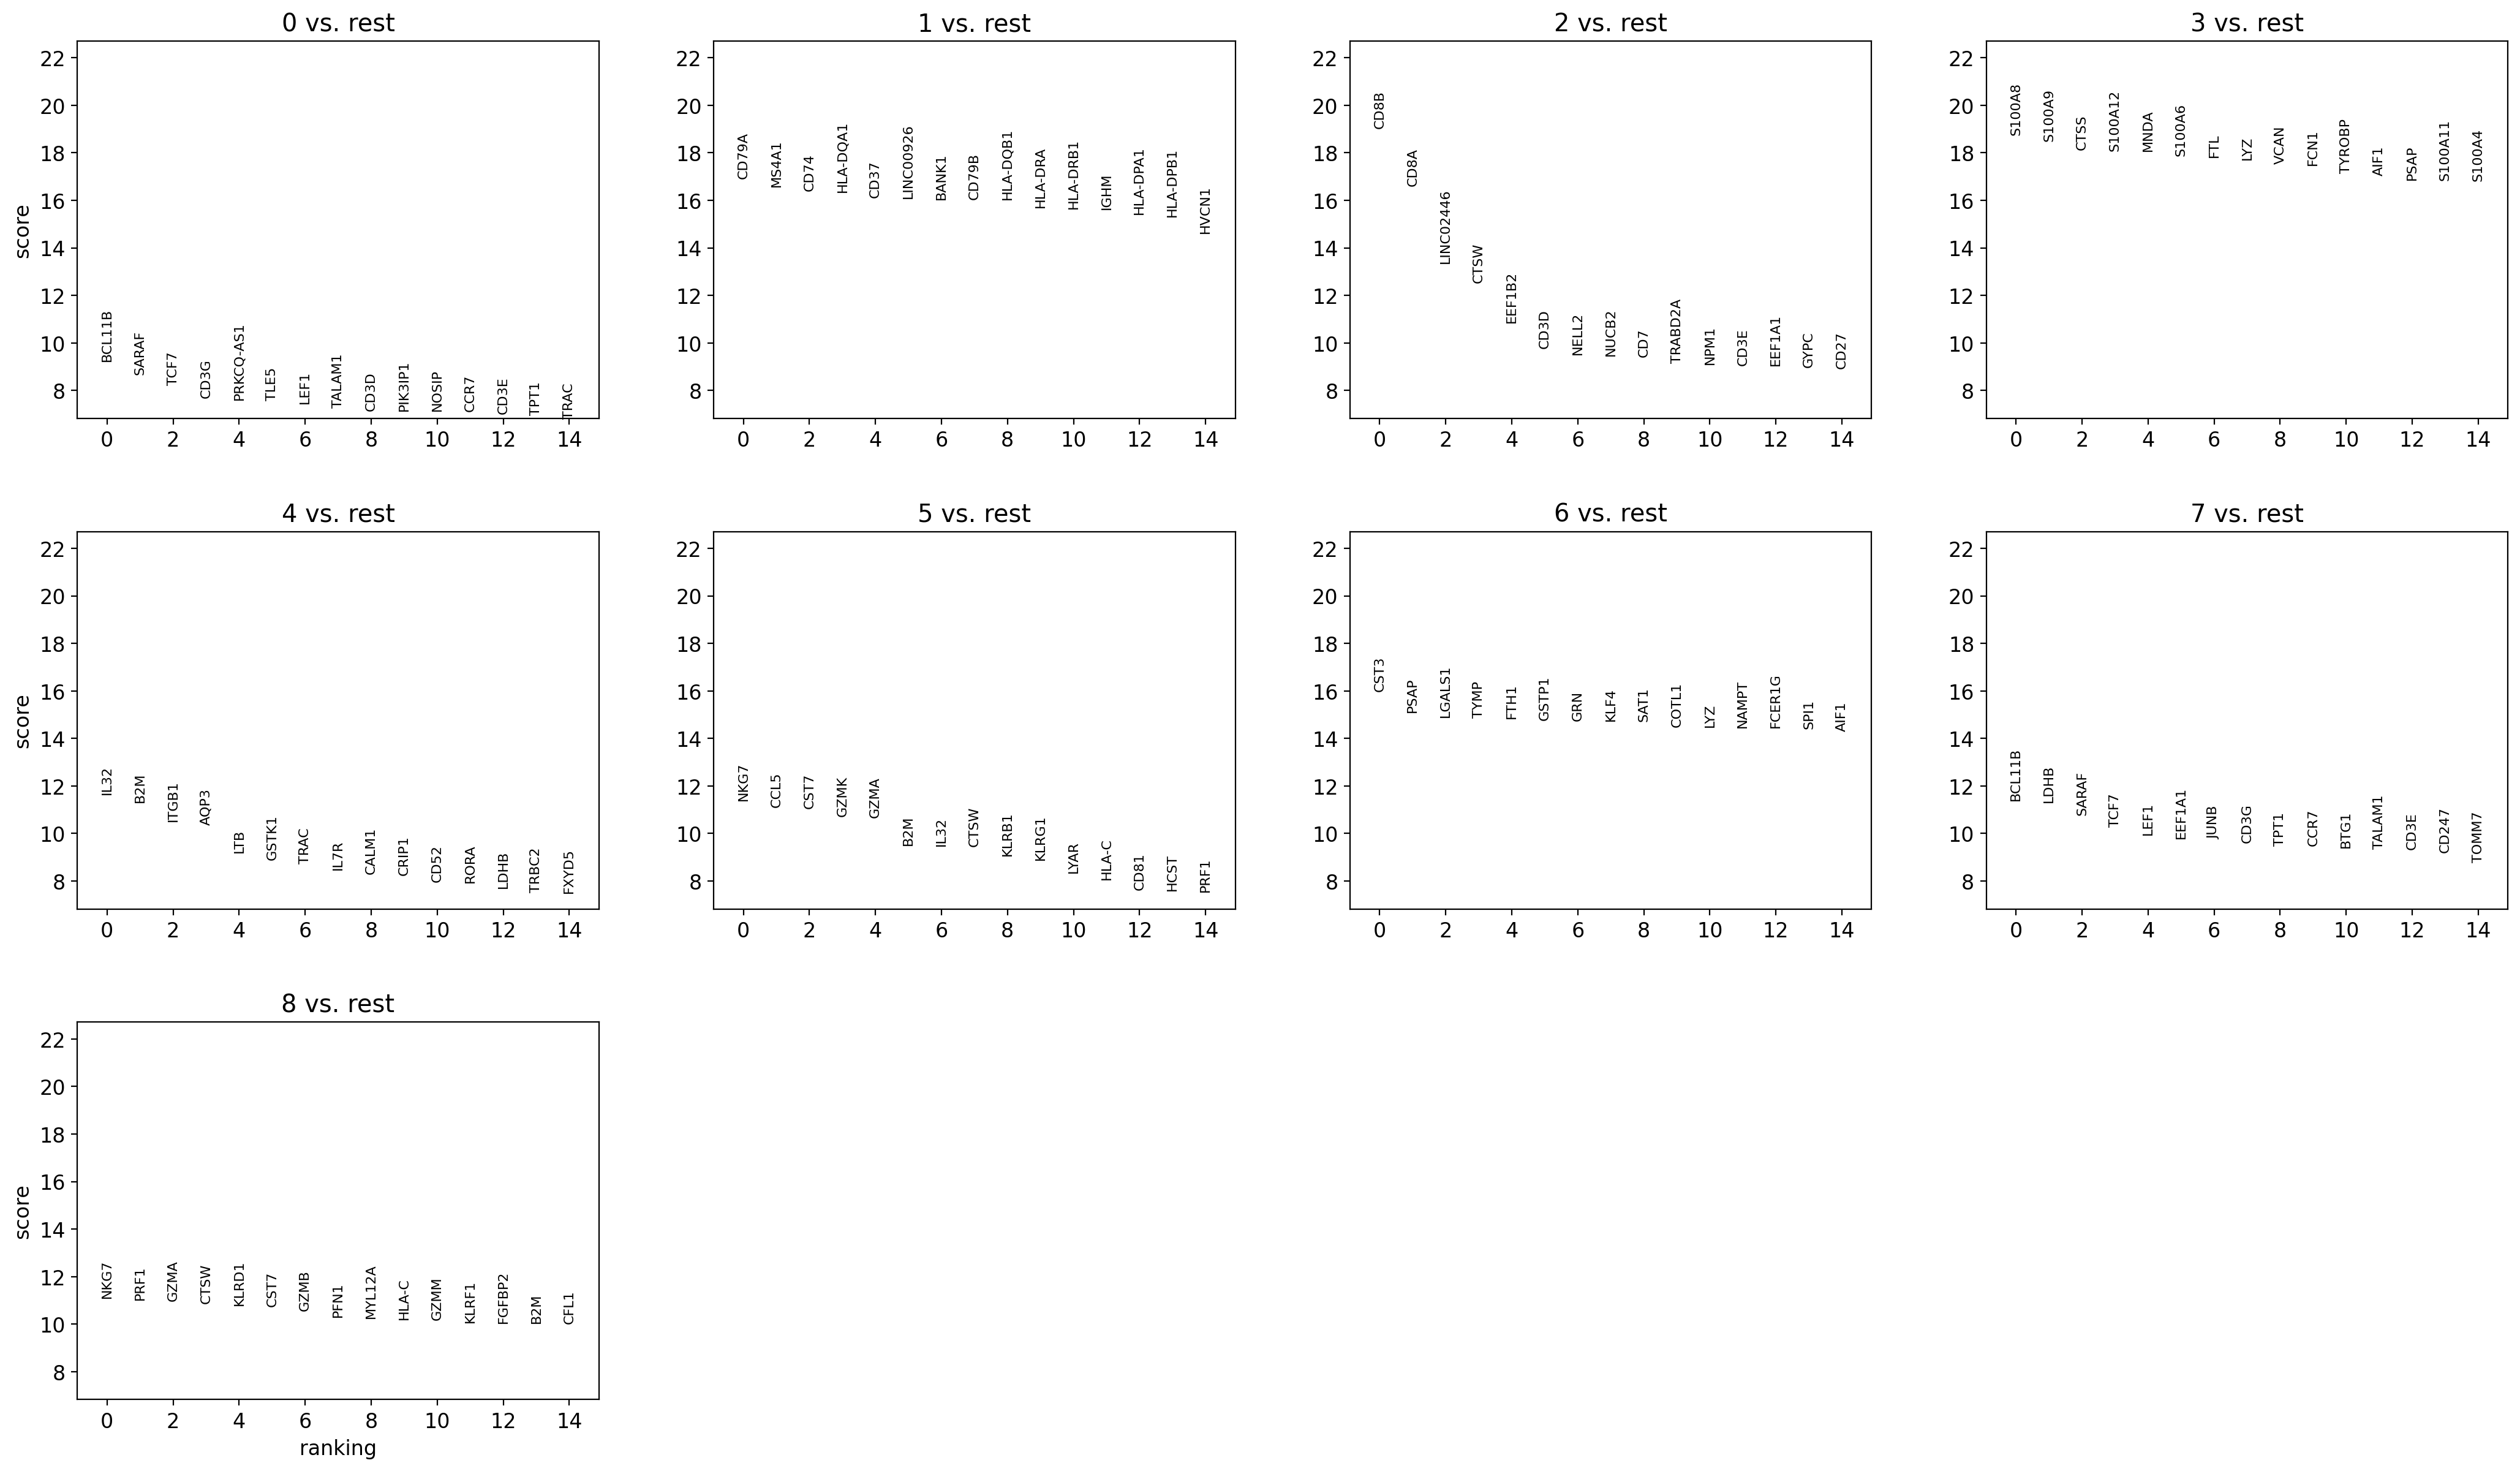

In [30]:
nuisance_genes = ['RPS', 'RPL', 'MALAT1', "MT-"]
adata = adata[:, ~adata.var['gene_names'].str.startswith(tuple(nuisance_genes))]
sc.tl.rank_genes_groups(adata, gene_symbols='gene_names', groupby='leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=15, gene_symbols='gene_names', groupby='leiden', method='wilcoxon')

Below we visualize the prevalence of these genes within a cluster and the mean cluster expression with a dot plot. We can see that most significant genes are expressed across several clusters. From the dot plot, we can group clusters into four broad cell-types: myeloid cells identified by CST3 (clusters 3 and 6), B cells identified by MS4A1 (cluster 1), T-cells identified by CD3G (clusters 2, 4, 5, 0, and 7), and cytotoxic lymphocytes identified by NKG7 (clusters 5 and 8). Finding more descriptive cell-types requires a more detailed inspection of the significant genes that we'll skip over here for simplicity. These plots are also useful for getting an idea of which genes make the best markers for this particular dataset and for identifying the presence of rare, unkown, or unexpected cell-types.

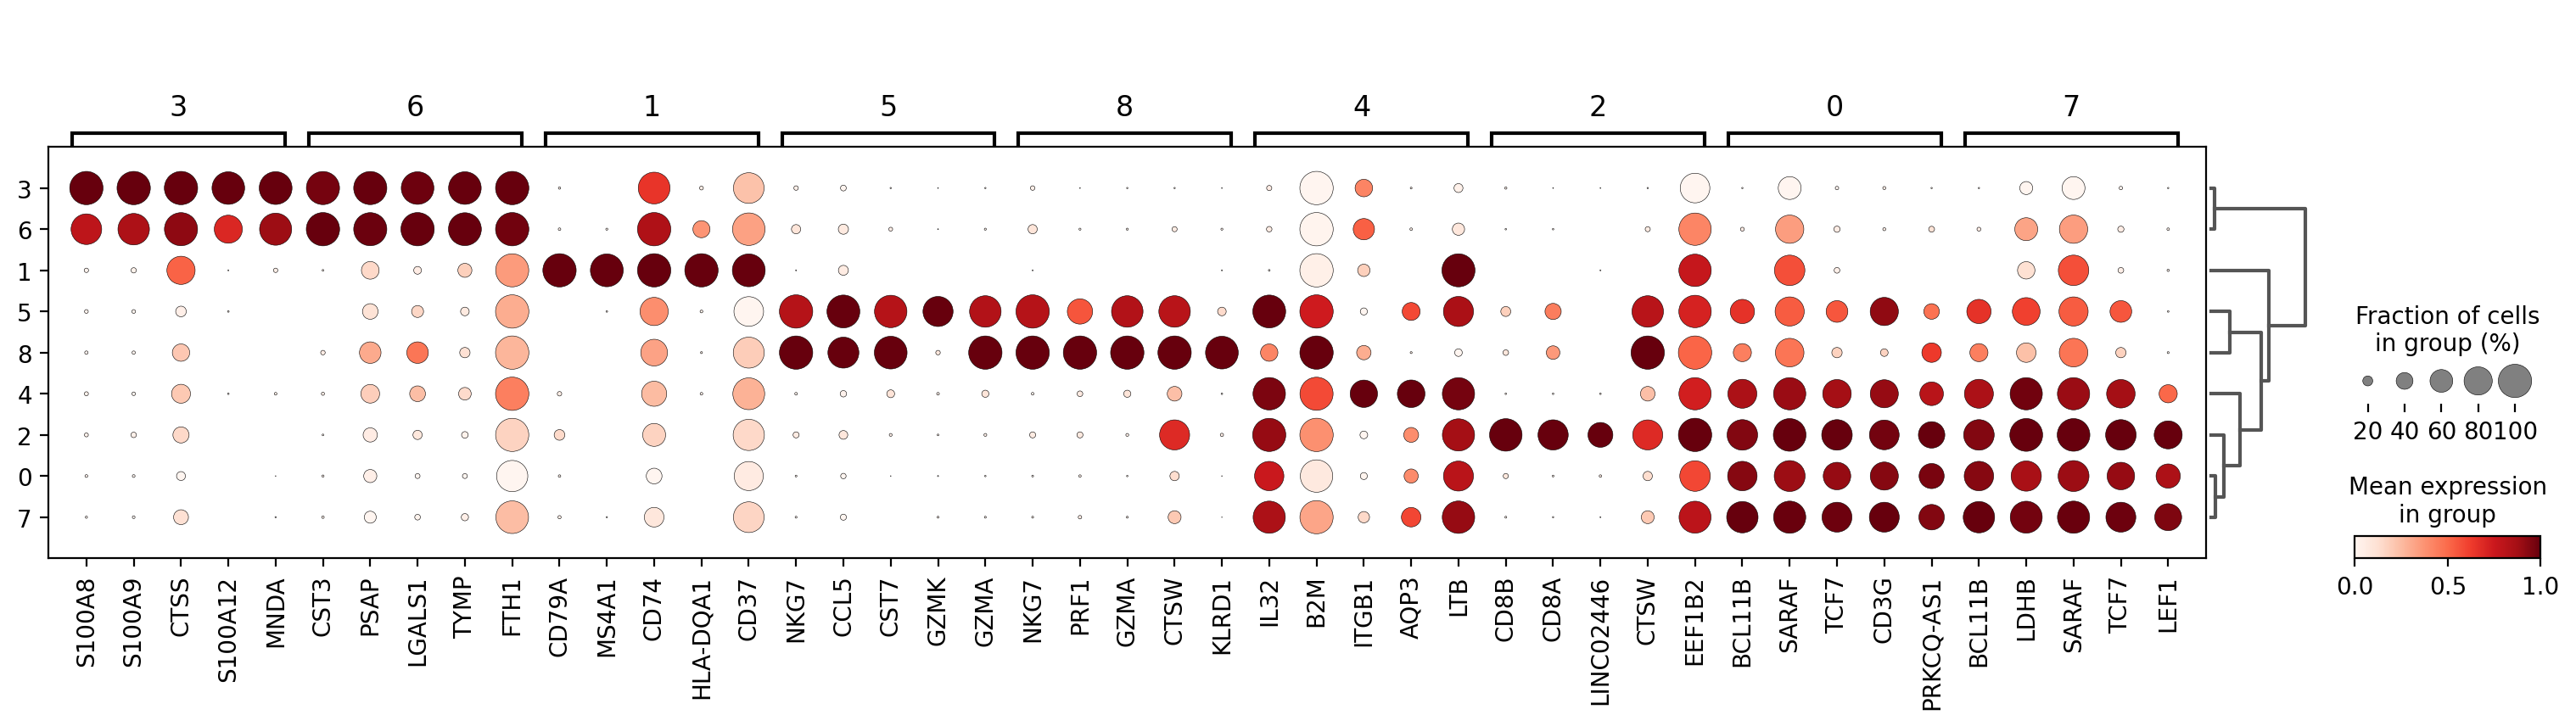

In [31]:
sc.tl.dendrogram(
    adata,
    groupby="leiden",
    key_added="dea_leiden"
)
sc.pl.rank_genes_groups_dotplot(
    adata, groupby="leiden", gene_symbols='gene_names', standard_scale="var", n_genes=5, dendrogram="dea_leiden"
)

### Annotation by Marker Gene Expression

If a tissue is well-studied, it is often easier to begin from known cell-type markers. Below is a minimal set of PBMC markers that we will use to differentiate between different cell-types. We will then plot a dot plot similar to the one above to see if we can identify the cell type of specific clusters.

In [32]:
## Minimal PBMC markers
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14", "LYZ"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN", "MS4A7"],
    "DC": ["FCER1A", "CST3"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "B cells": ["MS4A1", "IGHD", "IGHM"],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "GZMB", "CCL5"],
    "pan T": ["CD3D", "CD3E", "CD3G"]
}

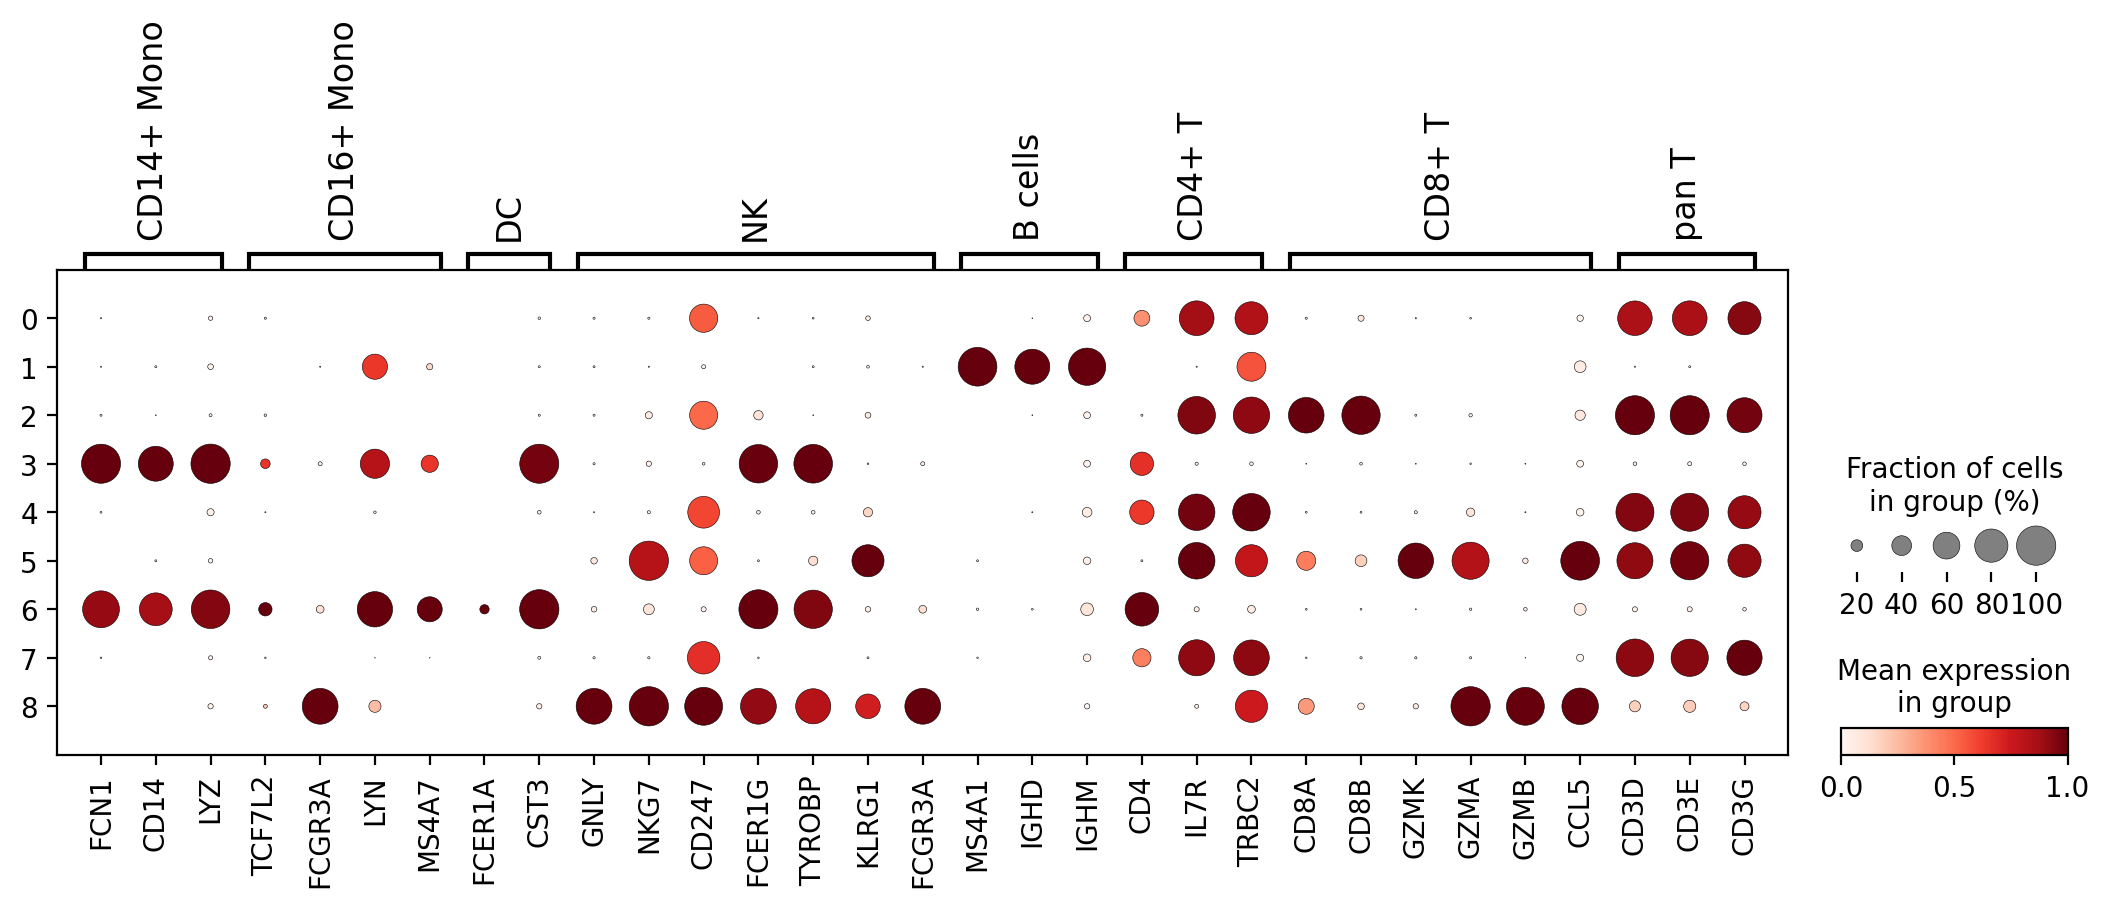

In [33]:
sc.pl.dotplot(adata, marker_genes, gene_symbols='gene_names', groupby="leiden", standard_scale="var")

From the dotplot, we can easily differentiate the broad PBMC cell types: monocytes (primarily CD14+), natural killer cells, B cells, and T cells. The T cells we can broadly differentiate into CD4+ and CD8+ cells. From the wilcoxon rank-sum test above, we know CD8+ T clusters represents cytotoxic T-cells (identified by GZMK and NKG7) while the other is composed of GZMK-CD8+ naive/central memory T-cells. There are two broad types of monocytes (CD14+ and CD16+). However, the fraction of CD16+ monocytes appears small relative to CD14+ monocytes and cannot be resolved with such a small dataset.

In [ ]:
annotation = {
    "0": "CD4+ T",
    "1": "B Cells",
    "2": "GZMK-CD8+ Naive/CM  T",
    "3": "Monocytes",
    "4": "CD4+ T",
    "5": "CD8+ T",
    "6": "Monocytes",
    "7": "CD4+ T",
    "8": "Natural Killer Cells",
}

We can then visualize the annotated clusters on the PCA projection.

In [37]:
adata.obs['cell_type'] = adata.obs['leiden'].map(annotation)

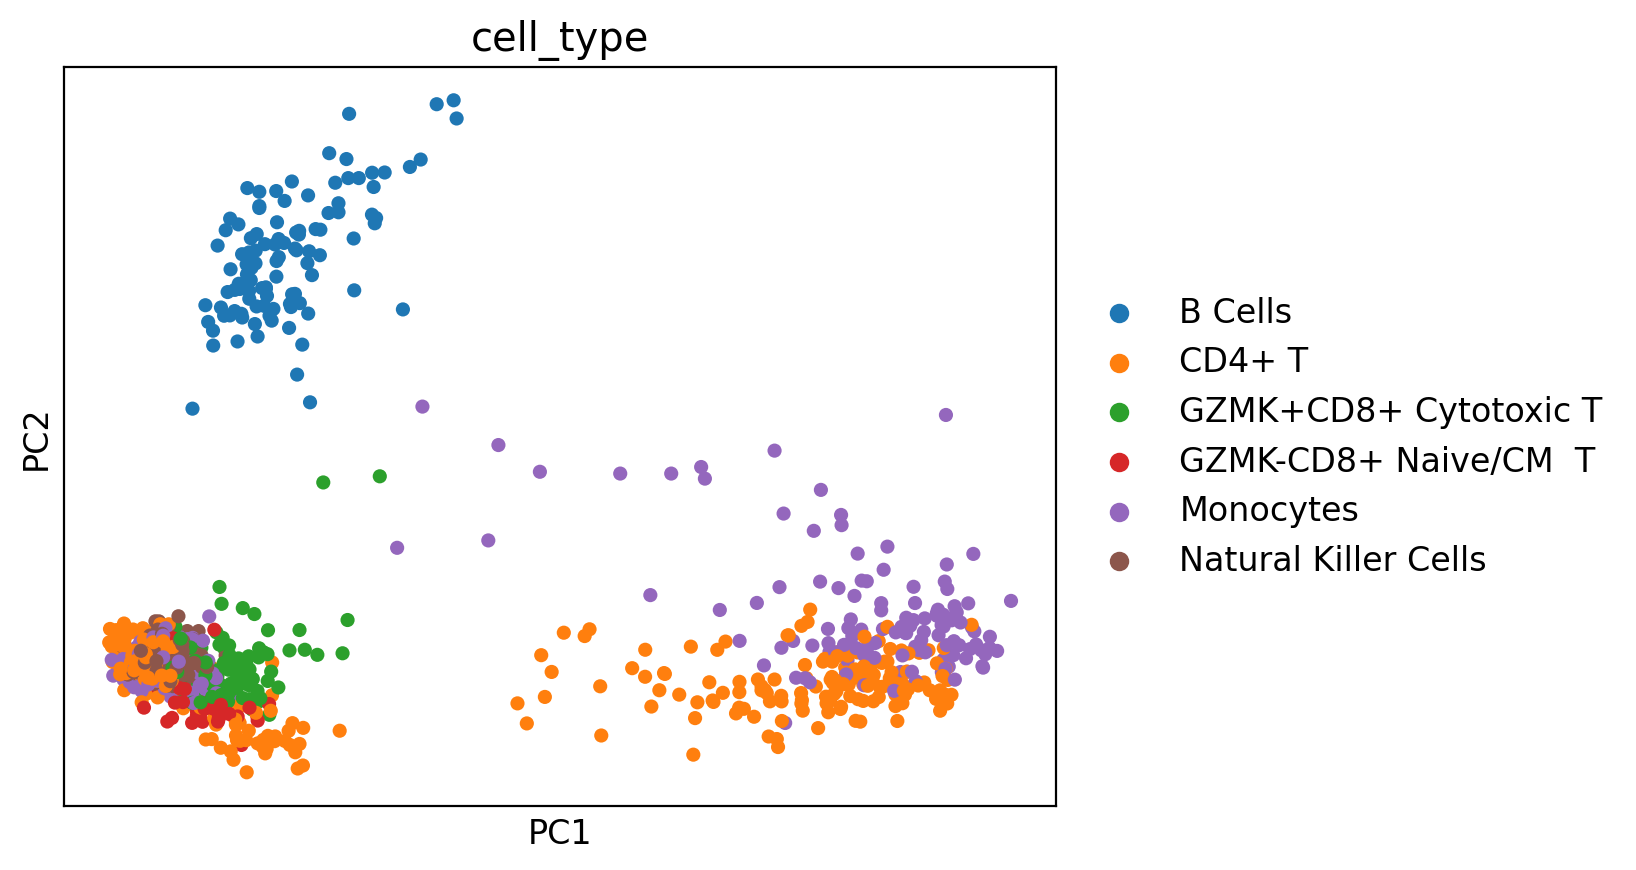

In [38]:
sc.pl.pca(adata, color='cell_type')

## Step 7: Differential Expression Analysis of Pseudobulk Data

Often, the aim of an scRNA-seq experiment is to identify genes that are differentially expressed between experimental conditions (for example, disease vs. healthy) within specific cell types. Differential expression (DE) analysis asks whether the expression of a gene differs systematically between groups of samples beyond what would be expected from natural biological variability. After cell type annotation, you might wish to compare gene expression between conditions within each cell type to determine how that cell population responds to the experimental perturbation.

However, individual cells should not be treated as independent biological replicates, because cells originating from the same sample share the same biological and technical sources of variation. A common solution is **pseudobulk analysis**, where counts from cells belonging to the same cell type and sample are aggregated to create a single expression profile per sample. This produces a matrix of gene counts that resembles bulk RNA-seq data while still preserving cell-type resolution. Differential expression analysis of pseudobulk data then proceeds identically to bulk RNA-seq analysis. To learn how to perform this analysis, see our [**Bulk RNA-seq Workflow**](/notebooks/bulk_workflow.ipynb).


### Preparing Data for Pseudobulk Analysis

DE tools perform their own normalization, variance modeling, and gene filtering. For this reason, pseudobulk counts should be generated from the **raw count matrix** rather than the processed data used for clustering and visualization. After identifying the clusters of cells we wish to analyze, we therefore return to the original count matrix, extract the cells belonging to the cell type(s) of interest, and aggregate their counts into pseudobulk samples.

This is typically done by starting with a count matrix containing cells from all samples (after cell filtering but before gene filtering), annotating each cell with its **sample** and **cell-type** labels, and then aggregating counts across cells within each group using `sc.get.aggregate`.

This converts the single-cell count matrix:

| Gene  | Cell1 | Cell2 | Cell3 | Cell4 | Cell5 |
|------|------|------|------|------|------|
| GeneA | 3 | 0 | 2 | 5 | 1 |
| GeneB | 0 | 1 | 0 | 3 | 2 |
| GeneC | 5 | 2 | 4 | 1 | 0 |


Into a pseudobulk count matrix where each column represents a **sample–cell-type combination**:

| Gene  | Sample1_Tcell | Sample2_Tcell | Sample1_Bcell |
|------|---------------|---------------|---------------|
| GeneA | 5 | 8 | 2 |
| GeneB | 1 | 4 | 7 |
| GeneC | 11 | 6 | 3 |

The resulting count matrix can then be exported to a CSV file and analyzed using standard bulk RNA-seq differential expression tools in R.